# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Global Feature Importance Comparison (bar chart)
5. Individual SHAP Scatter Plots — PC Graph
6. Individual SHAP Scatter Plots — LiNGAM Graph

## 1. Configuration & Imports

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "mixed_no_conf_f50_s1000_p50"
MODEL          = "lgbm"

# Number of top features (ranked by ShapleyFromScratch) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
LOGS_DIR           = BASE_DIR / "logs"

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")
print(f"Synthetic dir exists: {SYNTHETIC_DIR.exists()}")

Dataset : mixed_no_conf_f50_s1000_p50
Model   : lgbm
Top N   : 20
Synthetic dir exists: True


## 2. Pipeline Timing Summary

In [3]:
def parse_pipeline_timing(logs_dir: Path, dataset: str):
    """
    Parse the latest pipeline log and return:
      - timing_df  : per-method DataFrame (Method, Start, End, Duration, Per Instance, Graph Details)
      - total_str  : human-readable total execution time
    """
    log_files = sorted(logs_dir.glob("pipeline_*.log"))
    if not log_files:
        print("No log files found in", logs_dir)
        return None, "—"

    log_file = log_files[-1]
    print(f"Log file: {log_file.name}")

    ts_re   = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) \| (.*)$")
    prog_re = re.compile(r"\[Progress:\s*(\d+)/(\d+)\]\s+(.+)")

    events = []
    with open(log_file) as f:
        for line in f:
            m = ts_re.match(line.strip())
            if m:
                ts = datetime.strptime(m.group(1), "%Y-%m-%d %H:%M:%S")
                events.append((ts, m.group(2).strip()))

    # ── Extract ShapleyFlow graph stats per method (edges, sources) ─────
    # Format: "ShapleyFlowWrapper: 51 features, 138 edges, 9 sources"
    flow_re     = re.compile(r"ShapleyFlowWrapper:.*?(\d+) edges,\s*(\d+) sources")
    flow_stats  = {}          # keyed by progress-method-name string
    current_key = None
    for ts, content in events:
        pm = prog_re.search(content)
        if pm:
            current_key = pm.group(3).strip()
        fm = flow_re.search(content)
        if fm and current_key and current_key not in flow_stats:
            flow_stats[current_key] = (int(fm.group(1)), int(fm.group(2)))

    # ── Total execution time ─────────────────────────────────────────────
    total_min = None
    pipeline_end = None
    for ts, content in events:
        m = re.search(r"Total execution time:\s*([\d.]+)\s*minutes", content)
        if m:
            total_min    = float(m.group(1))
            pipeline_end = ts
    if pipeline_end is None and events:
        pipeline_end = events[-1][0]

    # ── Progress events ──────────────────────────────────────────────────
    prog_evts = []
    for ts, content in events:
        m = prog_re.search(content)
        if m:
            prog_evts.append({"ts": ts, "idx": int(m.group(1)), "name": m.group(3).strip()})

    if not prog_evts:
        return None, "—"

    # ── Build per-method rows ────────────────────────────────────────────
    rows = []
    for i, pe in enumerate(prog_evts):
        end_ts     = prog_evts[i + 1]["ts"] if i + 1 < len(prog_evts) else pipeline_end
        dur_s      = max(0.0, (end_ts - pe["ts"]).total_seconds()) if end_ts else 0.0
        dur_min    = dur_s / 60
        n_inst     = 100   # instances per method in the pipeline

        raw_name   = pe["name"]
        # Strip slow-warning annotation, e.g. "(SLOW - uses 10 inner samples)"
        clean_name = re.sub(r"\s*\(SLOW[^)]*\)", "", raw_name).strip()

        # ── Graph Details column ─────────────────────────────────────────
        is_pc     = "PC"     in raw_name.upper()
        is_lingam = "LINGAM" in raw_name.upper()
        is_flow   = "FLOW"   in raw_name.upper() or "ShapleyFlow" in raw_name

        if raw_name in flow_stats:
            edges, srcs = flow_stats[raw_name]
            graph_str = f"{edges} edges, {srcs} sources"
        elif is_pc:
            # Count from adjacency matrix for non-flow methods
            graph_str = "PC graph"
        elif is_lingam:
            graph_str = "LiNGAM graph"
        else:
            graph_str = "—"

        # ── Duration display ─────────────────────────────────────────────
        if dur_s < 5:
            dur_str  = "< 5 s (skipped)"
            per_str  = "—"
        elif dur_min >= 60:
            dur_str  = f"{dur_min/60:.1f} h  ({dur_min:.0f} min)"
            per_str  = f"~{dur_s/n_inst:.0f} s"
        elif dur_min >= 1:
            dur_str  = f"{dur_min:.1f} min"
            per_str  = f"~{dur_s/n_inst:.0f} s"
        else:
            dur_str  = f"{dur_s:.0f} s"
            per_str  = f"~{dur_s/n_inst:.1f} s"

        rows.append({
            "#":             pe["idx"],
            "Method":        clean_name,
            "Start":         pe["ts"].strftime("%H:%M:%S"),
            "End":           end_ts.strftime("%H:%M:%S") if end_ts else "—",
            "Duration":      dur_str,
            "Per Instance":  per_str,
            "Graph Details": graph_str,
        })

    total_str = (
        f"{total_min:.1f} min  ({total_min/60:.2f} h)" if total_min else "—"
    )
    return pd.DataFrame(rows), total_str


timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)

# ── Display as Plotly table ───────────────────────────────────────────────
if timing_df is not None:
    header_vals = list(timing_df.columns)
    cell_vals   = [timing_df[c].tolist() for c in timing_df.columns]

    # Zebra-stripe rows
    n = len(timing_df)
    row_colors = [["#f0f4f8" if i % 2 == 0 else "white" for i in range(n)]] * len(header_vals)

    fig_timing = go.Figure(go.Table(
        header=dict(
            values=[f"<b>{v}</b>" for v in header_vals],
            fill_color="#2c3e50", font=dict(color="white", size=12),
            align="left", height=30,
        ),
        cells=dict(
            values=cell_vals,
            fill_color=row_colors,
            align="left", height=26,
            font=dict(size=11),
        ),
    ))
    fig_timing.update_layout(
        title=dict(
            text=f"Pipeline Timing Summary — {DATASET}<br>"
                 f"<sup>Total execution time: {total_time}</sup>",
            font=dict(size=14),
        ),
        margin=dict(l=10, r=10, t=60, b=10),
        height=90 + 30 + n * 50,
    )
    fig_timing.show()
else:
    print("Could not parse timing log.")

Log file: pipeline_20260506_172253.log


## 3. Load Shapley Values

In [4]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────
def _flow_graph_stats(adj_list, n_x):
    """Return (total_edges, n_source_nodes) for a (n_x+1)×(n_x+1) adjacency."""
    adj   = np.array(adj_list)
    total = int(np.sum(adj != 0))
    # Backward BFS from Y (last node) to find ancestors
    n     = adj.shape[0]
    parents = {i: np.where(adj[:, i] != 0)[0].tolist() for i in range(n)}
    reachable, queue = set(), [n - 1]
    while queue:
        node = queue.pop()
        if node not in reachable:
            reachable.add(node)
            queue.extend(parents[node])
    # Source = in-degree 0 in X-only subgraph AND reachable from Y
    x_adj    = adj[:n_x, :n_x]
    in_deg   = np.sum(x_adj != 0, axis=0)
    sources  = [i for i in range(n_x) if in_deg[i] == 0 and i in reachable]
    return total, len(sources)

pc_edges,     pc_sources     = _flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = _flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

  Scratch                       shape=(100, 50)  mean|SHAP|=0.0227  NaN=0.0%  zeros=12.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.0235  NaN=0.0%  zeros=19.7%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.0300  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.0245  NaN=0.0%  zeros=43.9%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.0223  NaN=0.0%  zeros=22.3%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.0307  NaN=0.0%  zeros=2.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.0216  NaN=0.0%  zeros=22.6%

Features : 50    SHAP instances : 100
PC graph     : 138 edges, 9 sources
LiNGAM graph : 287 edges, 3 sources


## 4. Global Feature Importance Comparison

Mean absolute SHAP value per feature.  
**Left panel** — ShapleyFromScratch + PC-graph methods.  
**Right panel** — ShapleyFromScratch + LiNGAM-graph methods.  
Features are sorted (left → right) by ShapleyFromScratch importance.

In [5]:
# ── Mean absolute SHAP per feature ───────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# Top-N features ranked by Scratch
scratch_rank  = np.argsort(mean_abs["Scratch"])[::-1][:N_TOP_FEATURES]
top_features  = [feature_names[i] for i in scratch_rank]

# ── Build long-format DataFrame (one row per feature × method × graph) ───
PC_METHODS     = ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"]
LINGAM_METHODS = ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"]

rows = []
for method in PC_METHODS:
    src_key = "Scratch" if method == "Scratch" else method
    if src_key not in mean_abs:
        continue
    label = method.replace(" (PC)", "")
    for fi in scratch_rank:
        rows.append(dict(
            Feature=feature_names[fi],
            Method=label,
            Graph=f"PC  ({pc_edges} edges, {pc_sources} sources)",
            Importance=float(mean_abs[src_key][fi]),
        ))

for method in LINGAM_METHODS:
    src_key = "Scratch" if method == "Scratch" else method
    if src_key not in mean_abs:
        continue
    label = method.replace(" (LiNGAM)", "")
    for fi in scratch_rank:
        rows.append(dict(
            Feature=feature_names[fi],
            Method=label,
            Graph=f"LiNGAM  ({lingam_edges} edges, {lingam_sources} sources)",
            Importance=float(mean_abs[src_key][fi]),
        ))

df_imp = pd.DataFrame(rows)
df_imp["Feature"] = pd.Categorical(df_imp["Feature"], categories=top_features, ordered=True)

# ── Plot ──────────────────────────────────────────────────────────────────
fig_imp = px.bar(
    df_imp,
    x="Feature", y="Importance", color="Method",
    barmode="group",
    facet_col="Graph",
    facet_col_spacing=0.06,
    category_orders={
        "Feature": top_features,
        "Method":  ["Scratch", "Asymmetric", "Causal", "Flow"],
    },
    color_discrete_map={
        "Scratch":     METHOD_COLORS["Scratch"],
        "Asymmetric":  METHOD_COLORS["Asymmetric"],
        "Causal":      METHOD_COLORS["Causal"],
        "Flow":        METHOD_COLORS["ShapleyFlow"],
    },
    labels={"Importance": "Mean |SHAP|", "Feature": ""},
    title=(
        f"Global Feature Importance — Top {N_TOP_FEATURES} Features "
        f"(sorted by Scratch) — {DATASET}"
    ),
    height=480,
    width=1300,
)

# Shared y-axis so both panels are directly comparable
fig_imp.update_yaxes(matches="y")
fig_imp.update_layout(
    legend_title_text="Method",
    margin=dict(t=80, b=60),
)
fig_imp.show()

## 5. Individual SHAP Scatter Plots — PC Graph

Grid: **rows** = top-N features  ·  **columns** = [Scratch, Asymmetric, Causal, ShapleyFlow]  
Each cell: SHAP value (y) vs. feature value x (x) for all test instances.  
Y-axis scale is **shared within each row** so magnitudes are comparable across methods.

In [6]:
def make_shap_scatter_figure(
    methods:        list,   # ordered list of display names to use as columns
    col_labels:     list,   # short column header for each method
    feature_idx:    list,   # feature indices (rows)
    feature_labels: list,   # feature name for each row
    x_test:         np.ndarray,
    shap_data:      dict,
    title:          str,
    colors:         dict,
) -> go.Figure:
    """
    Build an (n_features × n_methods) scatter grid.
    Each cell: feature_value (x) vs SHAP_value (y).
    Y-axis is shared within each row.
    """
    n_rows = len(feature_idx)
    n_cols = len(methods)

    # ── Adaptive spacing ──────────────────────────────────────────────────
    # vertical_spacing is a fraction of total figure height.
    # With n_rows subplots the gaps consume  v * (n_rows - 1)  of that height.
    # Keep that budget ≤ 25 % of total so the actual subplots have room.
    # Formula: v = 0.25 / (n_rows - 1)  clamped to [0.005, 0.06]
    vertical_spacing   = max(0.005, min(0.06, 0.25 / max(n_rows - 1, 1)))
    horizontal_spacing = 0.06

    # Cell height scales so the total figure stays around 3 000 px.
    cell_h = max(120, 3000 // n_rows)

    # Column headers only in the top row; blank elsewhere
    subplot_titles = []
    for ri in range(n_rows):
        for ci in range(n_cols):
            subplot_titles.append(col_labels[ci] if ri == 0 else "")

    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=subplot_titles,
        shared_xaxes=False,
        shared_yaxes="rows",      # share y-scale within each feature row
        vertical_spacing=vertical_spacing,
        horizontal_spacing=horizontal_spacing,
    )

    # Style the column-header annotations produced by make_subplots
    for ann in fig.layout.annotations:
        if ann.text:
            ann.update(font=dict(size=11, color="#2c3e50"))

    for ri, (fi, feat) in enumerate(zip(feature_idx, feature_labels)):
        x_vals = x_test[:, fi]

        for ci, method in enumerate(methods):
            if method not in shap_data:
                continue
            shap_vals = shap_data[method][:, fi]

            fig.add_trace(
                go.Scatter(
                    x=x_vals,
                    y=shap_vals,
                    mode="markers",
                    marker=dict(
                        size=4,
                        color=x_vals,
                        colorscale="Viridis",
                        showscale=False,
                        opacity=0.7,
                        line=dict(width=0),
                    ),
                    name=method,
                    showlegend=False,
                    hovertemplate=(
                        f"<b>{feat}</b> — {method}<br>"
                        "x = %{x:.3f}<br>SHAP = %{y:.4f}<extra></extra>"
                    ),
                ),
                row=ri + 1, col=ci + 1,
            )

            # Zero-reference line
            x_range = [float(x_vals.min()), float(x_vals.max())]
            fig.add_trace(
                go.Scatter(
                    x=x_range, y=[0, 0],
                    mode="lines",
                    line=dict(color="gray", width=0.8, dash="dot"),
                    showlegend=False,
                    hoverinfo="skip",
                ),
                row=ri + 1, col=ci + 1,
            )

        # Feature name as y-axis label on the first column only
        fig.update_yaxes(
            title_text=feat,
            title_font=dict(size=9),
            title_standoff=4,
            row=ri + 1, col=1,
        )
        # Remove x-axis tick labels except on the last row to reduce clutter
        for ci in range(1, n_cols + 1):
            fig.update_xaxes(
                showticklabels=(ri == n_rows - 1),
                tickfont=dict(size=8),
                row=ri + 1, col=ci,
            )

    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        height=cell_h * n_rows + 80,
        width=240 * n_cols + 120,
        margin=dict(l=90, r=20, t=80, b=40),
    )
    return fig


# ── Column metadata ───────────────────────────────────────────────────────
PC_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (PC)",
    "Causal (PC)",
    "Flow (PC)",
]
COL_LABELS = ["ShapleyFromScratch", "AsymmetricShapley", "CausalShapley", "ShapleyFlow"]

fig_scatter_pc = make_shap_scatter_figure(
    methods        = PC_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    x_test         = x_test,
    shap_data      = shap_data,
    title          = (
        f"SHAP Scatter — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
    colors         = METHOD_COLORS,
)
fig_scatter_pc.show()

## 6. Individual SHAP Scatter Plots — LiNGAM Graph

Same grid structure as above but using LiNGAM-based causal methods.  
Scratch (no graph) is repeated here as the reference baseline.

In [7]:
LINGAM_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (LiNGAM)",
    "Causal (LiNGAM)",
    "Flow (LiNGAM)",
]

fig_scatter_lingam = make_shap_scatter_figure(
    methods        = LINGAM_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    x_test         = x_test,
    shap_data      = shap_data,
    title          = (
        f"SHAP Scatter — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
    colors         = METHOD_COLORS,
)
fig_scatter_lingam.show()

## 7. Instance-Level SHAP Values

Select `N_INSTANCES` random test instances and compare the per-feature SHAP values across methods for the **globally-ranked top features**.

| Axis | Meaning |
|------|---------|
| **Rows** | individual test instances |
| **Columns** | Shapley methods |
| **Bars** | SHAP value per feature (🔵 positive contribution, 🔴 negative contribution) |

Feature order is fixed to the global importance ranking (most important at top). This makes it easy to spot how attributions shift across instances and methods.

In [8]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


def make_instance_shap_figure(
    methods:        list,
    col_labels:     list,
    feature_idx:    list,
    feature_labels: list,
    instance_idx:   list,
    shap_data:      dict,
    title:          str,
) -> go.Figure:
    """
    (n_instances × n_methods) grid of horizontal bar charts.
    Each cell: SHAP values for the top-N features of one instance.
    Blue = positive contribution, red = negative contribution.
    Feature labels shown only in the first column; x-axis ticks only on last row.
    """
    n_rows  = len(instance_idx)
    n_cols  = len(methods)
    n_feats = len(feature_idx)

    # Adaptive row height: 22 px per bar + cell padding
    cell_h             = max(160, 22 * n_feats + 40)
    vertical_spacing   = max(0.005, min(0.04, 0.15 / max(n_rows - 1, 1)))
    horizontal_spacing = 0.06

    # Column headers in first row only, blank for all subsequent rows
    subplot_titles = [
        col_labels[ci] if ri == 0 else ""
        for ri in range(n_rows)
        for ci in range(n_cols)
    ]

    fig = make_subplots(
        rows=n_rows, cols=n_cols,
        subplot_titles=subplot_titles,
        shared_xaxes=False,
        shared_yaxes=False,
        vertical_spacing=vertical_spacing,
        horizontal_spacing=horizontal_spacing,
    )
    for ann in fig.layout.annotations:
        if ann.text:
            ann.update(font=dict(size=11, color="#2c3e50"))

    POS_COLOR = "#2196F3"   # blue  – positive SHAP contribution
    NEG_COLOR = "#EF5350"   # red   – negative SHAP contribution

    # Reverse order so the most important feature sits at the TOP of each bar chart
    feat_labels_top = feature_labels[::-1]
    feat_idx_top    = feature_idx[::-1]

    for ri, inst in enumerate(instance_idx):
        for ci, method in enumerate(methods):
            if method not in shap_data:
                continue

            sv     = shap_data[method][inst]
            vals   = np.array([sv[fi] for fi in feat_idx_top])
            colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in vals]

            fig.add_trace(
                go.Bar(
                    x=vals,
                    y=feat_labels_top,
                    orientation="h",
                    marker=dict(color=colors, line=dict(width=0)),
                    showlegend=False,
                    hovertemplate=(
                        f"<b>Instance {inst}</b><br>"
                        "%{y}: %{x:.4f}<extra></extra>"
                    ),
                ),
                row=ri + 1, col=ci + 1,
            )

            # Zero reference line
            fig.add_vline(
                x=0,
                line=dict(color="rgba(80,80,80,0.40)", width=1, dash="dot"),
                row=ri + 1, col=ci + 1,
            )

        # Instance index as y-axis title on first column only
        fig.update_yaxes(
            title_text=f"#{inst}",
            title_font=dict(size=9),
            title_standoff=3,
            showticklabels=True,
            tickfont=dict(size=8),
            row=ri + 1, col=1,
        )
        # Hide feature labels on columns 2 and beyond
        for ci in range(2, n_cols + 1):
            fig.update_yaxes(showticklabels=False, row=ri + 1, col=ci)

        # x-axis tick labels only on the last row
        for ci in range(1, n_cols + 1):
            fig.update_xaxes(
                showticklabels=(ri == n_rows - 1),
                tickfont=dict(size=8),
                row=ri + 1, col=ci,
            )

    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        height=cell_h * n_rows + 80,
        width=290 * n_cols + 140,
        margin=dict(l=90, r=20, t=80, b=40),
        bargap=0.10,
    )
    return fig


# ── PC Graph ──────────────────────────────────────────────────────────────
fig_instance_pc = make_instance_shap_figure(
    methods        = PC_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    instance_idx   = instance_idx,
    shap_data      = shap_data,
    title          = (
        f"Instance-Level SHAP — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
)
fig_instance_pc.show()

Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


In [9]:
# ── LiNGAM Graph ──────────────────────────────────────────────────────────
fig_instance_lingam = make_instance_shap_figure(
    methods        = LINGAM_SCATTER_METHODS,
    col_labels     = COL_LABELS,
    feature_idx    = scratch_rank.tolist(),
    feature_labels = top_features,
    instance_idx   = instance_idx,
    shap_data      = shap_data,
    title          = (
        f"Instance-Level SHAP — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
        f"Top {N_TOP_FEATURES} Features — {DATASET}"
    ),
)
fig_instance_lingam.show()

## 8. Sign Agreement Across Methods

**Metric definition** — for every *(instance i, feature f)* cell we count how many methods assign a positive SHAP value (`n⁺`) and how many assign a negative value (`n⁻`), then define:

$$\text{agreement}(i,f) = \frac{\max(n^+, n^-)}{n_{\text{methods}}} \in [0.5, \; 1.0]$$

| Score | Interpretation |
|-------|---------------|
| **1.0** | All methods agree on the sign (fully consistent) |
| **0.75** | 3 out of 4 methods agree |
| **0.5** | Half say +, half say − (maximally split) |

Three groups are evaluated: **PC Group** (Scratch + 3 PC methods), **LiNGAM Group** (Scratch + 3 LiNGAM methods), **All Methods** (all 7 together).

- **Feature-level bar chart** — mean agreement per feature (averaged over all test instances)
- **Heatmap** — full (feature × instance) agreement matrix, one panel per graph type

In [26]:
# ── Groups ────────────────────────────────────────────────────────────────
AGREEMENT_GROUPS = {
    "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"],
    "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"],
    # "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)"],
    # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)"],
    # "PC Group":     ["Scratch", "Asymmetric (PC)",     "Flow (PC)"],
    # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Flow (LiNGAM)"],
    # "PC Group":     ["Scratch", "Asymmetric (PC)",     ],
    # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", ],
    # "All Methods":  list(shap_data.keys()),
}
AGREEMENT_GROUPS["All Methods"]=AGREEMENT_GROUPS["PC Group"]+ AGREEMENT_GROUPS["LiNGAM Group"]
GROUP_COLORS_AGREE = {
    "PC Group":     "#1f77b4",
    "LiNGAM Group": "#e07b39",
    "All Methods":  "#2ca02c",
}

_feat_idx = np.array(scratch_rank.tolist())   # top-N feature indices


def compute_sign_agreement(method_list, shap_data, feat_idx):
    """
    For each (instance i, feature f): max(n_pos, n_neg) / n_methods.
    Returns
    -------
    agreement : ndarray (n_instances, n_feats)  ∈ [0.5, 1.0]
    available : list of method names actually used
    """
    available = [m for m in method_list if m in shap_data]
    if len(available) < 2:
        return None, available
    stack     = np.stack([shap_data[m][:, feat_idx] for m in available], axis=0)
    n_methods = stack.shape[0]
    signs     = np.sign(stack)                       # −1, 0, +1
    n_pos     = (signs > 0).sum(axis=0)              # (n_instances, n_feats)
    n_neg     = (signs < 0).sum(axis=0)
    return np.maximum(n_pos, n_neg) / n_methods, available


# ── Compute ───────────────────────────────────────────────────────────────
agreement_mats    = {}
agreement_methods = {}
for grp, methods in AGREEMENT_GROUPS.items():
    mat, avail             = compute_sign_agreement(methods, shap_data, _feat_idx)
    agreement_mats[grp]    = mat
    agreement_methods[grp] = avail

# ── Global summary table ──────────────────────────────────────────────────
print(f"{'Group':<18}  {'Global mean':>11}  {'Feat mean ± std':>18}  {'Inst mean ± std':>18}  # methods")
print("─" * 105)
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    feat_means = mat.mean(axis=0)      # (n_feats,)  mean over instances
    inst_means = mat.mean(axis=1)      # (n_inst,)   mean over features
    print(
        f"{grp:<18}  {mat.mean():>11.3f}  "
        f"{feat_means.mean():>7.3f} ± {feat_means.std():.3f}    "
        f"{inst_means.mean():>7.3f} ± {inst_means.std():.3f}  "
        f"  {len(agreement_methods[grp])}"
    )


# ── Figure A: Feature-level mean sign agreement ───────────────────────────
rows_agree = []
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    feat_means = mat.mean(axis=0)
    feat_stds  = mat.std(axis=0)
    for i, feat in enumerate(top_features):
        rows_agree.append(dict(
            Feature=feat,
            Group=grp,
            Agreement=float(feat_means[i]),
            Std=float(feat_stds[i]),
        ))

df_agree_feat = pd.DataFrame(rows_agree)
df_agree_feat["Feature"] = pd.Categorical(
    df_agree_feat["Feature"], categories=top_features, ordered=True
)

fig_agree_feat = px.bar(
    df_agree_feat,
    x="Feature", y="Agreement", color="Group",
    barmode="group",
    error_y="Std",
    color_discrete_map=GROUP_COLORS_AGREE,
    range_y=[0.45, 1.08],
    title=(
        f"Feature-Level Sign Agreement — Top {N_TOP_FEATURES} Features — {DATASET}<br>"
        f"<sup>Mean ± std over all {x_test.shape[0]} test instances.  "
        f"1.0 = all methods agree on direction, 0.5 = maximally split.</sup>"
    ),
    labels={"Agreement": "Mean Sign Agreement", "Feature": ""},
    height=460, width=1250,
)
fig_agree_feat.add_hline(
    y=0.75,
    line=dict(color="#636363", width=1, dash="dot"),
    annotation_text="75 % agree",
    annotation_position="top right",
    annotation_font_size=10,
)
fig_agree_feat.add_hline(
    y=0.5,
    line=dict(color="#d62728", width=1, dash="dash"),
    annotation_text="chance (0.5)",
    annotation_position="bottom right",
    annotation_font_size=10,
)
fig_agree_feat.update_layout(
    legend_title_text="Method Group",
    margin=dict(t=80, b=80),
    xaxis_tickangle=-35,
)
fig_agree_feat.show()

Group               Global mean     Feat mean ± std     Inst mean ± std  # methods
─────────────────────────────────────────────────────────────────────────────────────────────────────────
PC Group                  0.820    0.820 ± 0.094      0.820 ± 0.036    4
LiNGAM Group              0.836    0.836 ± 0.069      0.836 ± 0.037    4
All Methods               0.825    0.825 ± 0.077      0.825 ± 0.031    8


In [11]:
# ── Figure B: Heatmap — feature × all test instances ─────────────────────
# Two panels: PC Group (left) and LiNGAM Group (right)
hmap_groups = ["PC Group", "LiNGAM Group"]

fig_hmap = make_subplots(
    rows=1, cols=2,
    subplot_titles=hmap_groups,
    horizontal_spacing=0.08,
)

for ci, grp in enumerate(hmap_groups):
    mat = agreement_mats[grp]           # (n_instances, n_feats)
    if mat is None:
        continue

    # features on y-axis (most important at top), instances on x-axis
    z        = mat.T[::-1]              # (n_feats, n_instances)
    y_labels = top_features[::-1]

    fig_hmap.add_trace(
        go.Heatmap(
            z=z,
            x=[str(i) for i in range(mat.shape[0])],
            y=y_labels,
            colorscale="RdYlGn",
            zmin=0.5, zmax=1.0,
            showscale=(ci == 1),
            colorbar=dict(
                title=dict(text="Agreement", font=dict(size=11)),
                tickvals=[0.50, 0.625, 0.75, 0.875, 1.0],
                ticktext=["0.50 (split)", "0.63", "0.75", "0.88", "1.00 (full)"],
                x=1.02, len=0.85,
            ) if ci == 1 else {},
            hovertemplate=(
                "<b>%{y}</b><br>"
                "Instance %{x}: agreement = %{z:.3f}<extra></extra>"
            ),
        ),
        row=1, col=ci + 1,
    )

    # Annotate global mean for this group+panel
    g_mean = mat.mean()
    fig_hmap.add_annotation(
        text=f"mean = {g_mean:.3f}",
        xref=f"x{ci+1 if ci > 0 else ''} domain",
        yref=f"y{ci+1 if ci > 0 else ''} domain",
        x=0.98, y=1.04,
        showarrow=False,
        font=dict(size=10, color="#2c3e50"),
        align="right",
    )

fig_hmap.update_layout(
    title=dict(
        text=(
            f"Sign Agreement Heatmap — Feature × All Test Instances — {DATASET}<br>"
            "<sup>Red = split (0.50) · Yellow = partial · Green = full agreement (1.00)</sup>"
        ),
        font=dict(size=14),
    ),
    height=max(380, 22 * N_TOP_FEATURES + 110),
    width=1400,
    margin=dict(l=110, r=100, t=80, b=50),
)
fig_hmap.update_xaxes(tickfont=dict(size=7), tickangle=-60, title_text="Instance index")
fig_hmap.update_yaxes(tickfont=dict(size=9))
fig_hmap.show()

# ── Figure C: Instance-level mean agreement (aggregated over features) ────
rows_inst = []
for grp, mat in agreement_mats.items():
    if mat is None:
        continue
    inst_means = mat.mean(axis=1)   # (n_instances,)
    for i, v in enumerate(inst_means):
        rows_inst.append(dict(Instance=i, Group=grp, Agreement=float(v)))

df_inst = pd.DataFrame(rows_inst)

fig_agree_inst = px.line(
    df_inst,
    x="Instance", y="Agreement", color="Group",
    color_discrete_map=GROUP_COLORS_AGREE,
    markers=True,
    range_y=[0.45, 1.05],
    title=(
        f"Instance-Level Mean Sign Agreement — {DATASET}<br>"
        f"<sup>Each point = mean agreement over the top {N_TOP_FEATURES} features for that instance.</sup>"
    ),
    labels={"Agreement": "Mean Sign Agreement", "Instance": "Test Instance Index"},
    height=360, width=1100,
)
fig_agree_inst.add_hline(
    y=0.75, line=dict(color="#636363", width=1, dash="dot"),
    annotation_text="75 % agree", annotation_position="top right",
    annotation_font_size=10,
)
fig_agree_inst.update_layout(
    legend_title_text="Method Group",
    margin=dict(t=80, b=50),
)
fig_agree_inst.show()

## Section 9 — Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.


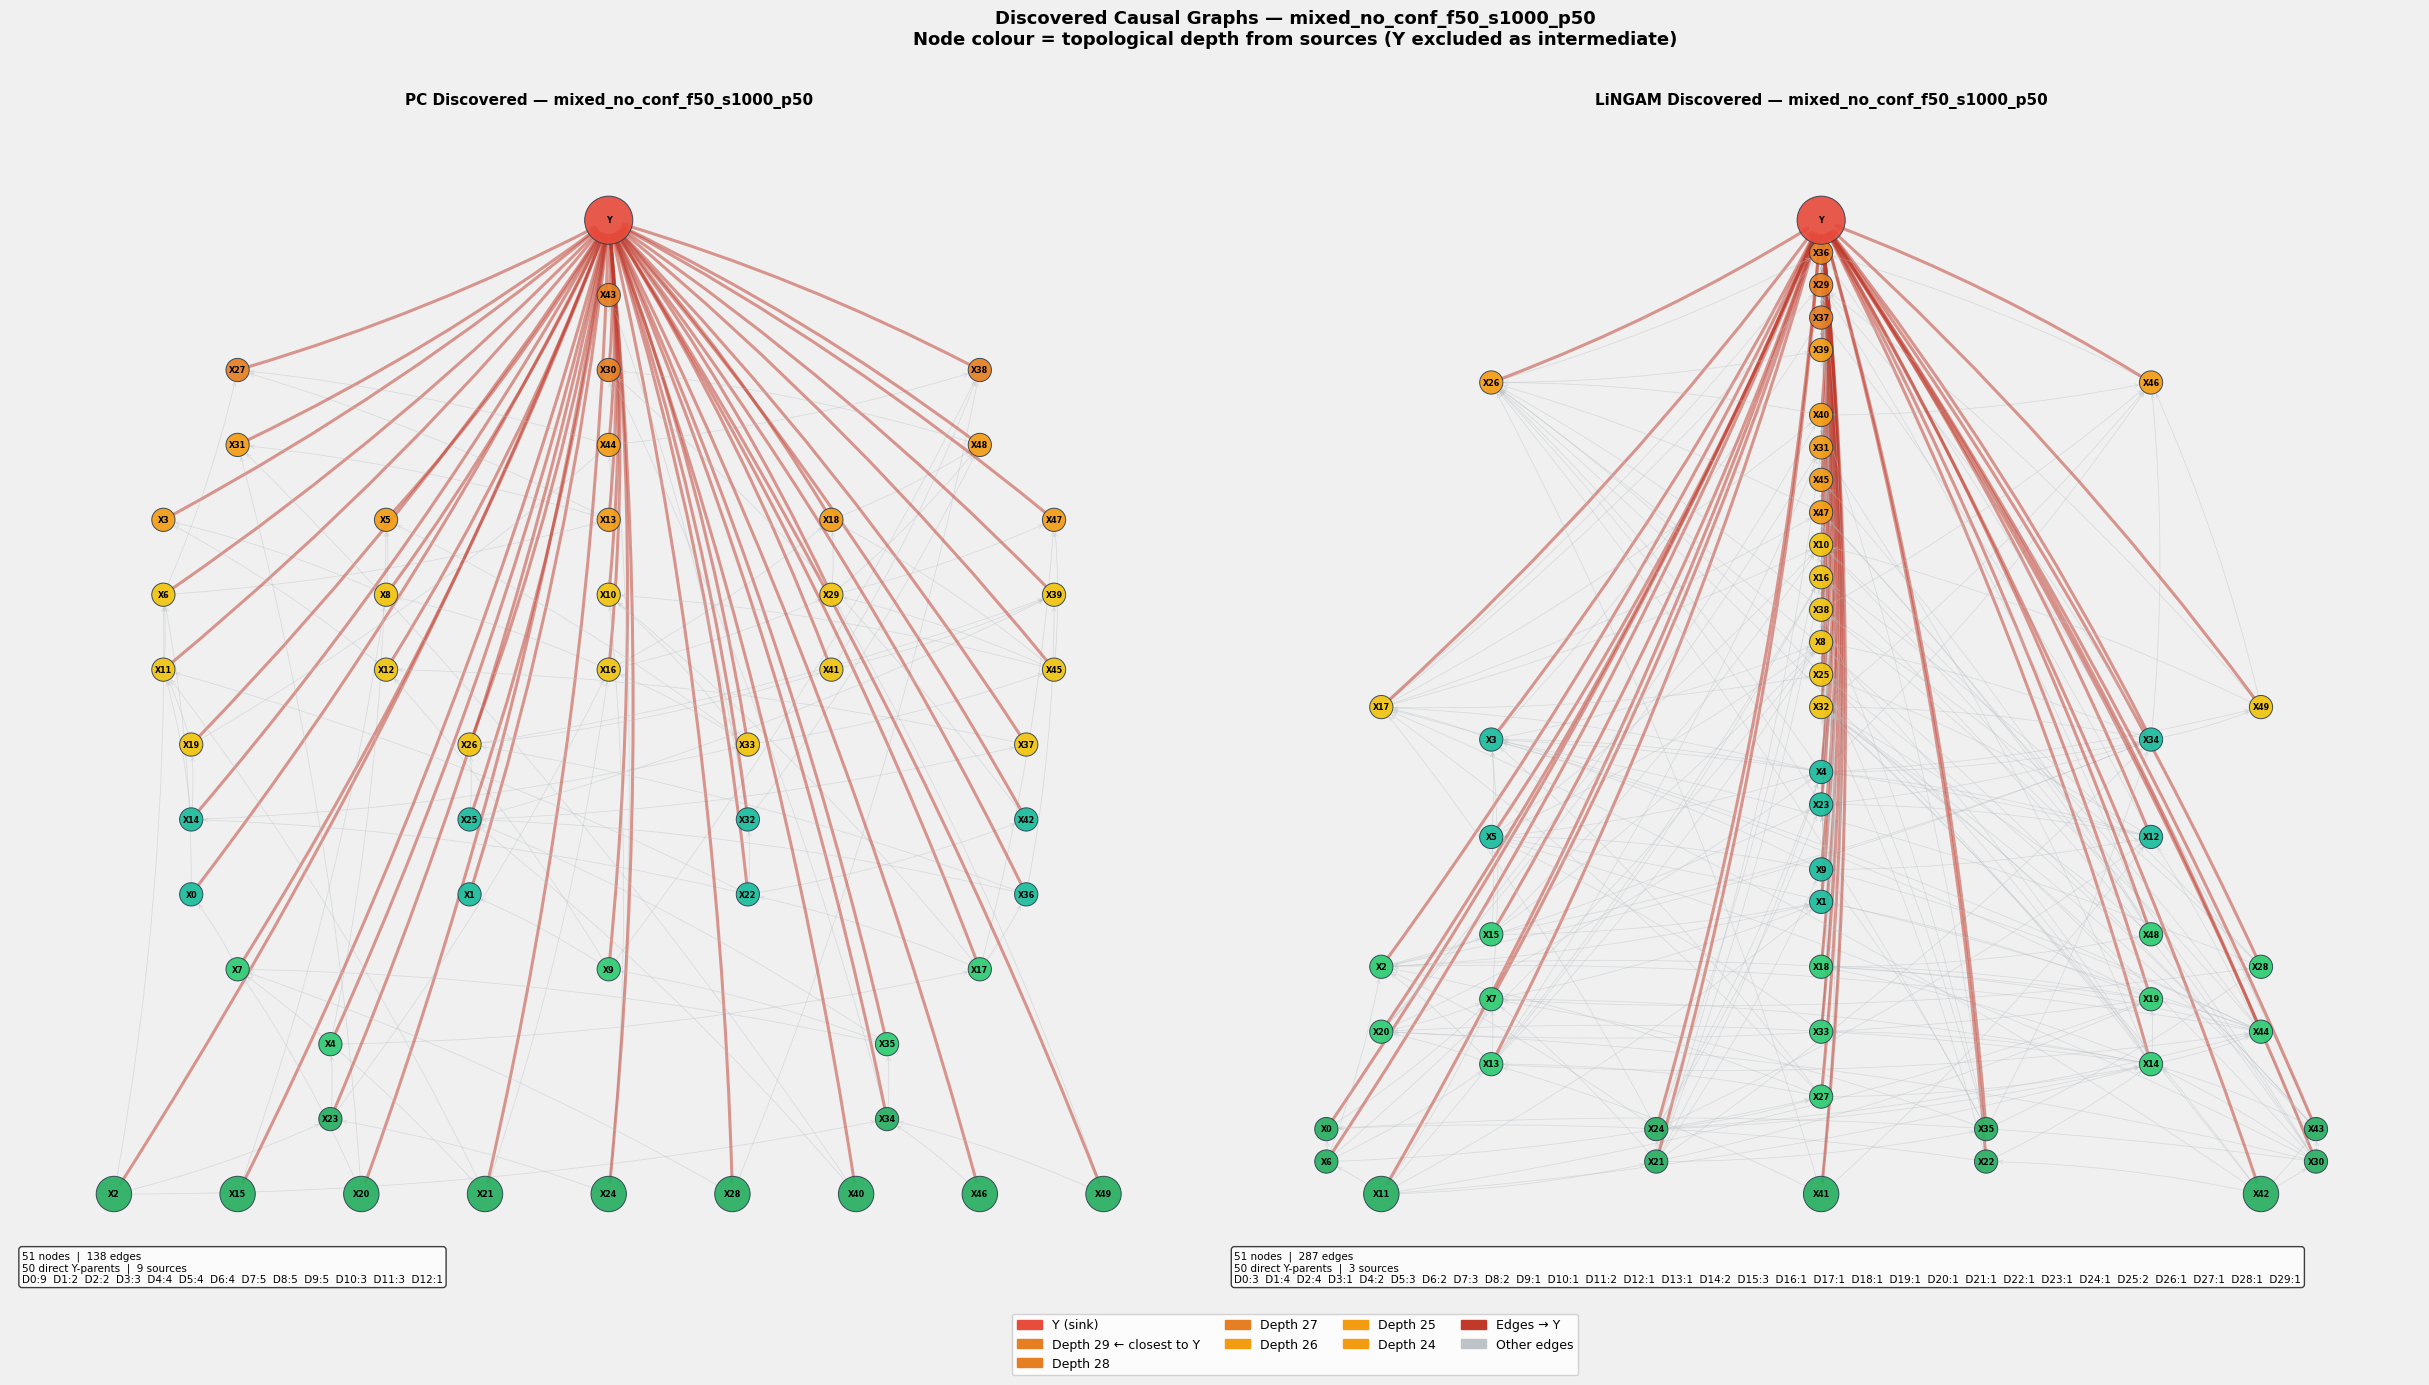

✅  Saved dag_comparison_mixed_no_conf_f50_s1000_p50.png

Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           51        51        51
  Total edges                          291       138       287
  Direct Y-parents                      25        50        50
  Source nodes (depth 0)                 3         9         3
  Max topo depth                        17        12        29
  Nodes at depth 0                       3         9         3
  Nodes at depth 1                       3         2         4
  Nodes at depth 2                       3         2         4
  Nodes at depth 3                       2         3         1
  Nodes at depth 4                       2         4         2
  Nodes at depth 5                       4         4         3
  Nodes at depth 6                       4         4         2
  Nodes at depth 7                       3         5    

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Load both discovery results + true adjacency for the current DATASET ─────
def load_dag(causal_dir, dataset, method):
    path = causal_dir / f"{dataset}_{method}_results.json"
    with open(path) as f:
        r = json.load(f)
    return np.array(r["adjacency_matrix"]), r["feature_names"]

pc_adj,     pc_names     = load_dag(CAUSAL_DIR, DATASET, "pc")
lingam_adj, lingam_names = load_dag(CAUSAL_DIR, DATASET, "lingam")

# True adjacency: stored as .npy, features identical to X0…X{n-1} + Y
true_adj   = np.load(SYNTHETIC_DIR / f"{DATASET}_adjacency.npy")
true_names = pc_names  # same feature ordering (X0…X{n-1}, Y)

# ── Helper: build graph + topological depth from sources ─────────────────────
def build_dag_graph(adj, names):
    n = len(names)
    y_idx = names.index("Y")

    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i, label=names[i])
    for i in range(n):
        for j in range(n):
            if adj[i, j] != 0:
                G.add_edge(i, j)

    parents_full = {i: [j for j in range(n) if adj[j, i] != 0] for i in range(n)}
    sources = {i for i in range(n) if len(parents_full[i]) == 0 and i != y_idx}

    non_y         = [i for i in range(n) if i != y_idx]
    children_no_y = {u: [v for v in range(n) if adj[u, v] != 0 and v != y_idx]
                      for u in non_y}
    parents_no_y  = {v: [] for v in non_y}
    for u, ch in children_no_y.items():
        for v in ch:
            parents_no_y[v].append(u)

    in_deg     = {nd: len(parents_no_y[nd]) for nd in non_y}
    topo_depth = {nd: 0 for nd in non_y}
    queue      = [nd for nd in non_y if in_deg[nd] == 0]
    while queue:
        node = queue.pop(0)
        for child in children_no_y.get(node, []):
            topo_depth[child] = max(topo_depth[child], topo_depth[node] + 1)
            in_deg[child] -= 1
            if in_deg[child] == 0:
                queue.append(child)

    max_depth = max(topo_depth.values()) if topo_depth else 0
    topo_depth[y_idx] = max_depth + 1

    level_groups = {}
    for nd, d in topo_depth.items():
        level_groups.setdefault(d, []).append(nd)
    for d in level_groups:
        level_groups[d].sort()

    return G, topo_depth, level_groups, sources, y_idx, max_depth

# ── Layout ────────────────────────────────────────────────────────────────────
def make_pos(level_groups, max_depth):
    Y_STEP  = 2.5
    H_SCALE = 1.4
    pos = {}
    for d, nodes in level_groups.items():
        n = len(nodes)
        h_gap = max(0.6, H_SCALE * 22 / max(n, 1))
        y_coord = -(max_depth + 1 - d) * Y_STEP
        for k, node in enumerate(nodes):
            pos[node] = ((k - (n - 1) / 2) * h_gap, y_coord)
    return pos

# ── Colour by proximity to Y ──────────────────────────────────────────────────
PROX_PALETTE = ["#e67e22", "#f39c12", "#f1c40f", "#1abc9c", "#2ecc71", "#27ae60"]

def _node_color(node_idx, topo_depth, max_depth, y_idx):
    if node_idx == y_idx:
        return "#e74c3c"
    prox = max_depth - topo_depth.get(node_idx, 0)
    if max_depth == 0:
        return PROX_PALETTE[0]
    idx = int(round(prox / max_depth * (len(PROX_PALETTE) - 1)))
    return PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]

# ── Draw one DAG onto an axis ─────────────────────────────────────────────────
def draw_dag(ax, G, pos, topo_depth, sources, y_idx, max_depth, title):
    nc = [_node_color(nd, topo_depth, max_depth, y_idx) for nd in G.nodes()]
    ns = [1200 if nd == y_idx else (650 if nd in sources else 280) for nd in G.nodes()]
    ec = ["#c0392b" if v == y_idx else "#bdc3c7" for u, v in G.edges()]
    ew = [2.2 if v == y_idx else 0.55 for u, v in G.edges()]

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ec, width=ew, alpha=0.5,
                           arrows=True, arrowstyle="->", arrowsize=7,
                           connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=nc, node_size=ns,
                           alpha=0.92, linewidths=0.7, edgecolors="#2c3e50")
    nx.draw_networkx_labels(G, pos, {nd: G.nodes[nd]["label"] for nd in G.nodes()},
                            ax=ax, font_size=5.8, font_weight="bold")

    n_direct   = sum(1 for u, v in G.edges() if v == y_idx)
    depth_dist = collections.Counter(v for k, v in topo_depth.items() if k != y_idx)
    stats_str  = (
        f"{G.number_of_nodes()} nodes  |  {G.number_of_edges()} edges\n"
        f"{n_direct} direct Y-parents  |  {len(sources)} sources\n"
        + "  ".join(f"D{d}:{depth_dist[d]}" for d in sorted(depth_dist))
    )
    ax.text(0.01, 0.01, stats_str, transform=ax.transAxes,
            fontsize=7.5, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75))
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.axis("off")
    ax.set_facecolor("#f8f9fa")

# ── Build all three graphs (also used by the True-graph cell below) ───────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_true   = make_pos(lvg_true,   ml_true)
pos_pc     = make_pos(lvg_pc,     ml_pc)
pos_lingam = make_pos(lvg_lingam, ml_lingam)

# ── Draw 2-panel figure: PC | LiNGAM ─────────────────────────────────────────
fig_dags, axes = plt.subplots(1, 2, figsize=(26, 14))
fig_dags.patch.set_facecolor("#f0f0f0")

draw_dag(axes[0], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         f"PC Discovered — {DATASET}")
draw_dag(axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         f"LiNGAM Discovered — {DATASET}")

max_lv_disc = max(ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), max_lv_disc + 1)):
    idx = int(round(prox / max(max_lv_disc, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_disc - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == max_lv_disc
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                   mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_dags.legend(handles=legend_entries, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_dags.suptitle(
    f"Discovered Causal Graphs — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.savefig(f"dag_comparison_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_comparison_{DATASET}.png")

# ── Comparison table: True | PC | LiNGAM ─────────────────────────────────────
rows = {}
for label, G, td, src, y_i, ml in [
    ("True",   G_true,   td_true,   src_true,   y_true,   ml_true),
    ("PC",     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ("LiNGAM", G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows[label] = {
        "nodes":      G.number_of_nodes(),
        "edges":      G.number_of_edges(),
        "direct_y":   sum(1 for u, v in G.edges() if v == y_i),
        "sources":    len(src),
        "max_depth":  ml,
        "depth_dist": collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f"{d[key]:>10}"

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print("─" * 64)
print(f"  {'Total nodes':<30}"          + "".join(_fmt(rows[m], "nodes")     for m in ["True","PC","LiNGAM"]))
print(f"  {'Total edges':<30}"          + "".join(_fmt(rows[m], "edges")     for m in ["True","PC","LiNGAM"]))
print(f"  {'Direct Y-parents':<30}"     + "".join(_fmt(rows[m], "direct_y")  for m in ["True","PC","LiNGAM"]))
print(f"  {'Source nodes (depth 0)':<30}" + "".join(_fmt(rows[m], "sources") for m in ["True","PC","LiNGAM"]))
print(f"  {'Max topo depth':<30}"       + "".join(_fmt(rows[m], "max_depth") for m in ["True","PC","LiNGAM"]))
max_d_all = max(rows[m]["max_depth"] for m in rows)
for d in range(max_d_all + 1):
    note = " (closest to Y)" if d == max_d_all else ""
    vals = "".join(f"{rows[m]['depth_dist'].get(d, 0):>10}" for m in ["True","PC","LiNGAM"])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery metrics ─────────────────────────────────────────────────────
def edge_recovery(true_adj, pred_adj):
    true_edges = set(zip(*np.where(true_adj != 0)))
    pred_edges = set(zip(*np.where(pred_adj != 0)))
    tp   = len(true_edges & pred_edges)
    prec = tp / len(pred_edges) if pred_edges else 0.0
    rec  = tp / len(true_edges) if true_edges  else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    return prec, rec, f1

pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

print(f"\n{'Edge Recovery (direction-aware)':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")

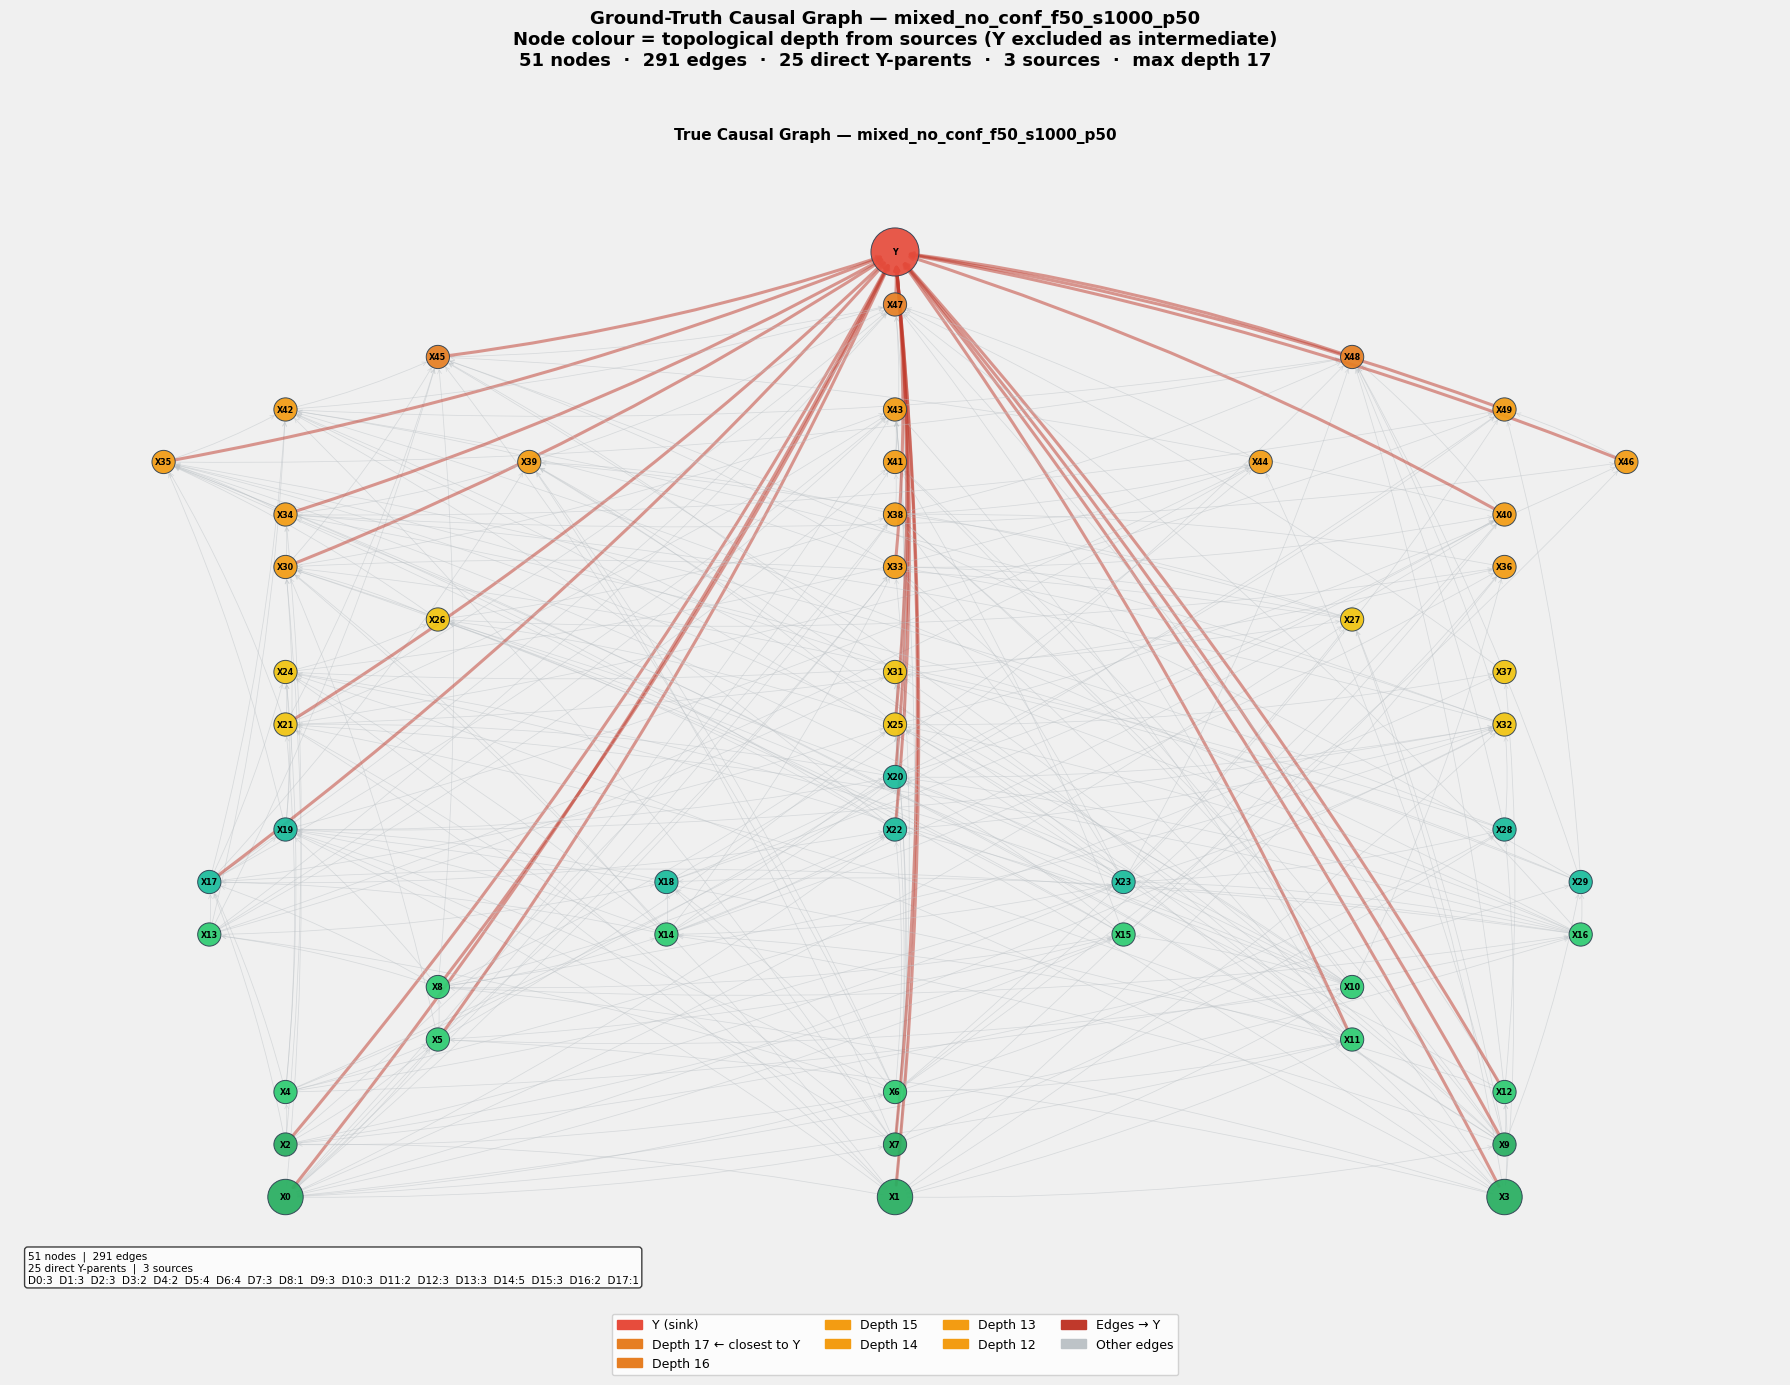

✅  Saved dag_true_mixed_no_conf_f50_s1000_p50.png


In [13]:
# ── True (ground-truth) causal graph — standalone panel ──────────────────────
fig_true, ax_true = plt.subplots(1, 1, figsize=(18, 14))
fig_true.patch.set_facecolor("#f0f0f0")

draw_dag(ax_true, G_true, pos_true, td_true, src_true, y_true, ml_true,
         f"True Causal Graph — {DATASET}")

# Legend
legend_entries_true = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), ml_true + 1)):
    idx = int(round(prox / max(ml_true, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = ml_true - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == ml_true
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries_true.append(mpatches.Patch(color=col, label=lbl))
legend_entries_true += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                        mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_true.legend(handles=legend_entries_true, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_true.suptitle(
    f"Ground-Truth Causal Graph — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)\n"
    f"{G_true.number_of_nodes()} nodes  ·  {G_true.number_of_edges()} edges  ·  "
    f"{sum(1 for u,v in G_true.edges() if v==y_true)} direct Y-parents  ·  "
    f"{len(src_true)} sources  ·  max depth {ml_true}",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig(f"dag_true_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_true_{DATASET}.png")

## Section 10 — Graph Sensitivity Analysis

**Goal**: quantify how much the choice of discovered graph (PC vs LiNGAM vs ground truth) changes the attributions produced by each causal Shapley method. This lets us answer the key thesis question:

> *Which method is causally aware but robust to graph quality?*

### Strategy

| Step | Metric | Graph variants | Instances used |
|------|--------|----------------|----------------|
| 10.1 | Compute true-graph Shapley values | True (ground truth) | Small fresh subset (`N_TRUE_INSTANCES`) |
| 10.2 | **Graph Sensitivity Score (GSS)** — normalized MAD between PC and LiNGAM attributions per feature | PC vs LiNGAM | All pre-computed instances |
| 10.3 | **Spearman ρ / Top-K Jaccard** — ranking robustness across graph variants | PC vs LiNGAM vs True | Subset (10.1) |
| 10.4 | **True-graph alignment** — distance from gold-standard attributions | PC→True, LiNGAM→True | Subset (10.1) |
| 10.5 | **Recommendation summary** — one score per method | All variants | — |

> **Run Section 3 first** (cells through "Load Shapley Values") to populate `shap_data`, `feature_names`, `x_test`, etc.

In [ ]:
"""
10.1 — Compute all 3 causal methods × 3 graph variants on a small fresh test subset.

Results are cached to disk so the kernel can be restarted without re-running (~20 min).
Cache path: data/explainability/{DATASET}/subset_shap_cache/
Delete the cache file (or the whole directory) to force a full recompute.

Cache v2: True-graph full_adj now built using LGBM model features + sink nodes,
          matching run_causal_discovery (previously used raw true_adj Y-edges directly).

Requires: model + data files on disk; true_adj, pc_adj, lingam_adj in kernel.
"""
import sys, time, importlib
sys.path.insert(0, str(BASE_DIR))

from predictive_models.predictive_models import LGBMRegressor
from explainability_models import AsymmetricShapley, CausalShapley, ShapleyFlowWrapper
from scipy.stats import spearmanr

# ── Hyperparameters (tune for speed vs. accuracy) ────────────────────────────
N_TRUE_INSTANCES = 20   # instances to run all methods on (↑ for stability)
N_SAMPLES_ASYM   = 50   # MC permutations for AsymmetricShapley
N_SAMPLES_CAUSAL = 50   # outer MC for CausalShapley
M_INNER          = 5    # inner do-samples for CausalShapley (↑ for accuracy)
N_SAMPLES_FLOW   = 50   # MC permutations for ShapleyFlow
RANDOM_STATE_10  = 42

# ── Cache path (v2: True-graph full_adj fixed) ────────────────────────────────
_cache_dir  = EXPLAINABILITY_DIR / DATASET / "subset_shap_cache"
_cache_file = _cache_dir / f"subset_shap_N{N_TRUE_INSTANCES}_R{RANDOM_STATE_10}_v2.npz"

if _cache_file.exists():
    print(f"✅  Loading cached subset_shap_data from {_cache_file}")
    _loaded = np.load(_cache_file, allow_pickle=False)
    subset_shap_data = {k: _loaded[k] for k in _loaded.files}
    # Re-derive feat_names_10 from parquet (arrays don't carry column names)
    _train_tmp = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_train.parquet")
    feat_names_10 = [c for c in _train_tmp.drop(columns=["Y"]).columns]
    # Re-derive test_sub_10 for downstream cells that need it
    _test_tmp   = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
    X_train_10  = _train_tmp.drop(columns=["Y"]); y_train_10 = _train_tmp["Y"]
    X_test_10   = _test_tmp.drop(columns=["Y"]);  y_test_10  = _test_tmp["Y"]
    bg_10       = X_train_10.sample(n=int(len(X_train_10) * 0.3), random_state=RANDOM_STATE_10)
    test_sub_10 = X_test_10.sample(n=N_TRUE_INSTANCES, random_state=RANDOM_STATE_10)
    y_sub_10    = y_test_10.loc[test_sub_10.index]
    bg_flow_10  = bg_10.copy();       bg_flow_10["Y"]  = y_train_10.loc[bg_10.index]
    test_flow_10 = test_sub_10.copy(); test_flow_10["Y"] = y_sub_10
    true_adj_xx = true_adj[:len(feat_names_10), :len(feat_names_10)]
    pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
    lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")
    model_10 = LGBMRegressor.load(str(BASE_DIR / "models" / f"{DATASET}_lgbm"))
    print(f"   {len(subset_shap_data)} arrays loaded.  "
          f"Shape: {list(subset_shap_data.values())[0].shape}")
else:
    print(f"⏳  Cache not found (v2). Computing subset_shap_data (~5–20 min)…")

    # ── Load model & data ──────────────────────────────────────────────────────
    _models_dir = BASE_DIR / "models"
    model_10 = LGBMRegressor.load(str(_models_dir / f"{DATASET}_lgbm"))

    train_df_10 = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_train.parquet")
    test_df_10  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")

    X_train_10 = train_df_10.drop(columns=["Y"]); y_train_10 = train_df_10["Y"]
    X_test_10  = test_df_10.drop(columns=["Y"]);  y_test_10  = test_df_10["Y"]

    feat_names_10 = [c for c in X_train_10.columns]   # X0…X{n-1}, no Y

    bg_10       = X_train_10.sample(n=int(len(X_train_10) * 0.3), random_state=RANDOM_STATE_10)
    test_sub_10 = X_test_10.sample(n=N_TRUE_INSTANCES, random_state=RANDOM_STATE_10)
    y_sub_10    = y_test_10.loc[test_sub_10.index]

    bg_flow_10   = bg_10.copy();       bg_flow_10["Y"]   = y_train_10.loc[bg_10.index]
    test_flow_10 = test_sub_10.copy(); test_flow_10["Y"] = y_sub_10

    true_adj_xx = true_adj[:len(feat_names_10), :len(feat_names_10)]

    with open(CAUSAL_DIR / f"{DATASET}_pc_results.json")     as f: _pc_r     = json.load(f)
    with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f: _lingam_r = json.load(f)

    pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
    lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")

    # ── Build True-graph full adjacency (same logic as run_causal_discovery) ──
    # Start with true X→X edges, then add X→Y edges for:
    #   • every feature used by the LGBM model (selected_features)
    #   • every sink node in true_adj_xx (no outgoing X→X edges)
    # This matches how pc_adj/lingam_adj are built — do NOT use raw true_adj Y-edges
    # directly, as they reflect data-generation parents, not model-guided structure.
    _n_feat = len(feat_names_10)
    true_full_adj = np.zeros((_n_feat + 1, _n_feat + 1), dtype=int)
    true_full_adj[:_n_feat, :_n_feat] = true_adj_xx
    for _feat in model_10.selected_features:
        if _feat in feat_names_10:
            _fi = feat_names_10.index(_feat)
            true_full_adj[_fi, _n_feat] = 1
    for _fi in range(_n_feat):
        if true_adj_xx[_fi, :].sum() == 0:
            true_full_adj[_fi, _n_feat] = 1
    _y_edges = int(true_full_adj[:_n_feat, _n_feat].sum())
    print(f"  True DAG: {int(true_adj_xx.sum())} X→X edges + {_y_edges} X→Y edges "
          f"({len(model_10.selected_features)} model features, sink-node rule applied)")

    GRAPH_CONFIGS = {
        "PC":     (pc_adj,        pc_train_adj_xx,     _pc_r["confounders"]),
        "LiNGAM": (lingam_adj,    lingam_train_adj_xx, _lingam_r["confounders"]),
        "True":   (true_full_adj, true_adj_xx,         []),
    }

    # ── Compute ────────────────────────────────────────────────────────────────
    subset_shap_data = {}

    for graph_label, (full_adj, xx_adj, confounders) in GRAPH_CONFIGS.items():
        key = f"Asymmetric ({graph_label})"
        print(f"  ▶ {key} ...", end=" ", flush=True)
        t0 = time.time()
        _exp = AsymmetricShapley(model_10, bg_10, causal_graph=full_adj,
                                  n_samples=N_SAMPLES_ASYM, random_state=RANDOM_STATE_10)
        subset_shap_data[key] = _exp.explain(test_sub_10, method="monte_carlo")
        print(f"{time.time()-t0:.1f}s")

        key = f"Causal ({graph_label})"
        print(f"  ▶ {key} ...", end=" ", flush=True)
        t0 = time.time()
        _exp = CausalShapley(model_10, background_data=bg_10,
                              discovered_adj=xx_adj, discovered_conf=confounders,
                              feature_names=feat_names_10,
                              n_samples=N_SAMPLES_CAUSAL, M_inner_samples=M_INNER,
                              random_state=RANDOM_STATE_10)
        subset_shap_data[key] = _exp.explain(test_sub_10)
        print(f"{time.time()-t0:.1f}s")

        key = f"Flow ({graph_label})"
        print(f"  ▶ {key} ...", end=" ", flush=True)
        t0 = time.time()
        _exp = ShapleyFlowWrapper(model=model_10, background_data=bg_flow_10,
                                   causal_graph=full_adj, y_index=len(feat_names_10),
                                   n_samples=N_SAMPLES_FLOW, random_state=RANDOM_STATE_10)
        subset_shap_data[key] = _exp.explain(test_flow_10)
        print(f"{time.time()-t0:.1f}s")

    # ── Save cache ─────────────────────────────────────────────────────────────
    _cache_dir.mkdir(parents=True, exist_ok=True)
    np.savez(_cache_file, **subset_shap_data)
    print(f"\n💾  Saved to {_cache_file}")

print(f"\n✅  Done. {len(subset_shap_data)} arrays, each shape {list(subset_shap_data.values())[0].shape}")
print("\nSanity — mean |SHAP| per method:")
for k, v in subset_shap_data.items():
    print(f"  {k:<30}  mean|φ|={np.abs(v).mean():.4f}  zeros={100*(v==0).mean():.1f}%")

✅  Loading cached subset_shap_data from /Users/juanrios/Documents/master_thesis/data/explainability/mixed_no_conf_f50_s1000_p50/subset_shap_cache/subset_shap_N20_R42.npz
LightGBM model loaded from /Users/juanrios/Documents/master_thesis/models/mixed_no_conf_f50_s1000_p50_lgbm.pkl
   9 arrays loaded.  Shape: (20, 50)

✅  Done. 9 arrays, each shape (20, 50)

Sanity — mean |SHAP| per method:
  Asymmetric (PC)                 mean|φ|=0.0255  zeros=20.3%
  Causal (PC)                     mean|φ|=0.0406  zeros=0.0%
  Flow (PC)                       mean|φ|=0.0248  zeros=49.2%
  Asymmetric (LiNGAM)             mean|φ|=0.0237  zeros=23.0%
  Causal (LiNGAM)                 mean|φ|=0.0394  zeros=2.0%
  Flow (LiNGAM)                   mean|φ|=0.0224  zeros=27.2%
  Asymmetric (True)               mean|φ|=0.0254  zeros=16.2%
  Causal (True)                   mean|φ|=0.0469  zeros=0.0%
  Flow (True)                     mean|φ|=0.0189  zeros=23.0%


## 10.2 — Graph Sensitivity Score (GSS)

The **Graph Sensitivity Score** measures how much the choice of causal discovery algorithm (PC vs LiNGAM) changes the **importance magnitude** assigned to each feature. It operates on absolute Shapley values so that sign flips that preserve magnitude do not inflate the score:

$$
\text{GSS}(m, f) = \frac{\displaystyle\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m,\,\text{PC})}_{i,f}| - |\varphi^{(m,\,\text{LiNGAM})}_{i,f}|\,\Bigr|}{\displaystyle\max_{m'}\;\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m',\,\text{PC})}_{i,f}| - |\varphi^{(m',\,\text{LiNGAM})}_{i,f}|\,\Bigr|}
$$

where $m$ is the causal Shapley method (Asymmetric, Causal, Flow), $f$ is a feature, $n$ is the number of instances, and $\varphi^{(m,\,g)}_{i,f}$ is the Shapley value of feature $f$ for instance $i$ under method $m$ with graph $g$.

The denominator is the **per-feature maximum** of this magnitude difference across methods, bounding **GSS $\in [0,\,1]$** for every feature:

- **GSS = 0** — both graphs assign the same importance magnitude (the feature matters equally under PC and LiNGAM).
- **GSS = 1** — this method shows the largest importance-magnitude shift for this feature across all methods.

This normalisation answers: *"relative to the most sensitive method, how much does graph choice change the importance of feature $f$ for method $m$?"* A method with low mean GSS is **robust** to which causal discovery algorithm was used.

In [29]:
"""
10.2 — Graph Sensitivity Score (GSS): PC vs LiNGAM

Uses the full pre-computed shap_data (all n_shap instances).
Shows:
  A) Feature-level GSS heatmap  — which features are most sensitive to graph choice?
  B) Per-instance magnitude delta box plots — top features by Scratch importance
  C) Method-level GSS summary table

GSS(method, feature) = mean_i ||φ(PC,i,f)| - |φ(LiNGAM,i,f)|| / max_per_feat(f)

max_per_feat(f) = max over methods of mean_i ||φ(PC,i,f)| - |φ(LiNGAM,i,f)||
→ GSS ∈ [0, 1] per feature: 1.0 = the most importance-magnitude-sensitive method.
   Features where all methods give identical values for both graphs → max=0 → GSS = N/A.
   Sign flips that preserve magnitude contribute 0 (graphs agree on importance).
"""

CAUSAL_METHOD_PAIRS = [
    ("Asymmetric", "Asymmetric (PC)",  "Asymmetric (LiNGAM)"),
    ("Causal",     "Causal (PC)",      "Causal (LiNGAM)"),
    ("Flow",       "Flow (PC)",        "Flow (LiNGAM)"),
]

# ── Compute mean absolute magnitude differences ───────────────────────────────
# ||φ(PC)| - |φ(LiNGAM)|| per instance, then averaged across instances
raw_diffs  = {}
feat_delta = {}
for label, pc_key, lingam_key in CAUSAL_METHOD_PAIRS:
    if pc_key not in shap_data or lingam_key not in shap_data:
        continue
    abs_pc     = np.abs(shap_data[pc_key])               # (n_inst, n_feat)
    abs_lingam = np.abs(shap_data[lingam_key])           # (n_inst, n_feat)
    mag_diff   = np.abs(abs_pc - abs_lingam)             # (n_inst, n_feat)
    raw_diffs[label]  = mag_diff.mean(axis=0)            # (n_feat,)
    feat_delta[label] = abs_pc - abs_lingam              # signed mag delta for box plots

# Per-feature normalizer: max mean magnitude diff across methods for each feature
all_raw      = np.stack(list(raw_diffs.values()), axis=0)  # (n_methods, n_feat)
max_per_feat = all_raw.max(axis=0)                          # (n_feat,)
n_zero_denom = (max_per_feat == 0).sum()
print(f"Per-feature max — mean={max_per_feat.mean():.6f}  "
      f"min={max_per_feat.min():.6f}  max={max_per_feat.max():.6f}  "
      f"zero_denom={n_zero_denom} (GSS=N/A for these features)")

# Divide only where denominator > 0; features with max=0 get NaN (all methods identical)
gss_feat = {}
for label, arr in raw_diffs.items():
    with np.errstate(invalid="ignore"):
        gss_feat[label] = np.where(max_per_feat > 0, arr / max_per_feat, np.nan)

# ── A: Feature-level GSS heatmap (horizontal: methods = rows, features = cols) ──
gss_matrix = np.stack([gss_feat[m] for m in ["Asymmetric","Causal","Flow"]], axis=1)
# sort features by mean GSS descending → highest-sensitivity features on the left
feat_order     = np.argsort(np.nanmean(gss_matrix, axis=1))[::-1]
top_feats_gss  = min(40, len(feature_names))
feat_order_top = feat_order[:top_feats_gss]

METHOD_LABELS = ["Asymmetric", "Causal", "Flow"]
# Transpose so z shape is (n_methods, n_feats) → methods on y, features on x
gss_z_T = gss_matrix[feat_order_top].T   # (3, top_feats_gss)

fig_gss_hmap = go.Figure(go.Heatmap(
    z          = gss_z_T,
    y          = METHOD_LABELS,
    x          = [feature_names[i] for i in feat_order_top],
    colorscale = "YlOrRd",
    zmin=0, zmax=1.0,
    colorbar=dict(
        title=dict(text="GSS", font=dict(size=11)),
        tickvals=[0, 0.25, 0.5, 0.75, 1.0],
        ticktext=["0 (none)", "0.25", "0.5", "0.75", "1.0 (most sensitive)"],
    ),
    hovertemplate="<b>%{y}</b> — %{x}<br>GSS = %{z:.3f}<extra></extra>",
))
fig_gss_hmap.update_layout(
    title=dict(
        text=(
            f"Feature-Level Graph Sensitivity Score — PC vs LiNGAM — {DATASET}<br>"
            f"<sup>GSS = mean||φ(PC)|−|φ(LiNGAM)|| / max_per_feature.  "
            f"1.0 = most magnitude-sensitive method for that feature.  "
            f"Top {top_feats_gss} features sorted left→right by mean GSS descending.</sup>"
        ),
        font=dict(size=13),
    ),
    height=310,
    width=max(800, 20 * top_feats_gss + 200),
    xaxis=dict(tickfont=dict(size=8), tickangle=-45, side="bottom"),
    yaxis=dict(tickfont=dict(size=10)),
    margin=dict(l=110, r=80, t=85, b=110),
)
fig_gss_hmap.show()

# ── B: Per-instance magnitude delta — Scratch top-N features ─────────────────
# |φ(PC)| - |φ(LiNGAM)| per instance: positive = PC assigns higher importance
fig_delta_rows = []
for label, _, _ in CAUSAL_METHOD_PAIRS:
    if label not in feat_delta:
        continue
    for fi in scratch_rank:          # ← scratch_rank from Section 4
        for v in feat_delta[label][:, fi]:
            fig_delta_rows.append(dict(Feature=feature_names[fi], Method=label, Delta=float(v)))

df_delta = pd.DataFrame(fig_delta_rows)
df_delta["Feature"] = pd.Categorical(
    df_delta["Feature"],
    categories=[feature_names[i] for i in scratch_rank], ordered=True
)

fig_delta = px.box(
    df_delta,
    x="Feature", y="Delta", color="Method",
    color_discrete_map={
        "Asymmetric": METHOD_COLORS["Asymmetric"],
        "Causal":     METHOD_COLORS["Causal"],
        "Flow":       METHOD_COLORS["ShapleyFlow"],
    },
    points="outliers",
    title=(
        f"Per-Instance Importance Magnitude Delta |φ(PC)| − |φ(LiNGAM)| — "
        f"Top {N_TOP_FEATURES} Features by Scratch — {DATASET}<br>"
        f"<sup>Positive = PC assigns higher importance; negative = LiNGAM assigns higher.  "
        f"Tight boxes = consistent effect; wide boxes = instance-specific sensitivity.</sup>"
    ),
    labels={"Delta": "|φ(PC)| − |φ(LiNGAM)|", "Feature": ""},
    height=480, width=1300,
)
fig_delta.add_hline(y=0, line=dict(color="black", width=1, dash="dash"))
fig_delta.update_layout(xaxis_tickangle=-40, legend_title_text="Method", margin=dict(t=90, b=80))
fig_delta.show()

# ── C: Method-level GSS summary ───────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max GSS':>9}  "
      f"{'Feat GSS>0.5':>13}  {'Feat GSS>0.25':>14}")
print("─" * 80)
for label in ["Asymmetric", "Causal", "Flow"]:
    if label not in gss_feat:
        continue
    g    = gss_feat[label]
    valid = ~np.isnan(g)
    print(f"  {label:<13}  {np.nanmean(g):>10.4f}  {np.nanmedian(g):>11.4f}  "
          f"{np.nanmax(g):>9.4f}  {(g[valid]>0.5).sum():>13d}  {(g[valid]>0.25).sum():>14d}")

Per-feature max — mean=0.028108  min=0.009183  max=0.096527  zero_denom=0 (GSS=N/A for these features)



Method             Mean GSS   Median GSS    Max GSS   Feat GSS>0.5   Feat GSS>0.25
────────────────────────────────────────────────────────────────────────────────
  Asymmetric         0.2871       0.2149     1.0000             10              23
  Causal             0.7859       0.8314     1.0000             44              50
  Flow               0.8333       1.0000     1.0000             43              49


In [16]:
"""
10.3 — Ranking robustness vs Scratch & True-parent recovery

A) Spearman ρ  — rank corr of mean|φ| per feature: each method+graph vs Scratch
B) Top-K Jaccard vs Scratch — feature set overlap with the graph-free baseline
C) True-parent Precision@K — how many of the top-K features are real Y-parents?

A/B/C use shap_data (all n_shap instances, same as rest of notebook).
True-Graph Alignment (TGA) has moved to Section 11.
"""
BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]
K_VALUES     = [5, 10, 20]

# ── Load true Y-parent set ────────────────────────────────────────────────────
with open(SYNTHETIC_DIR / f"{DATASET}_metadata.json") as _f:
    _meta = json.load(_f)
y_parent_set = set(_meta["y_parent_indices"])
print(f"True Y-parents: {len(y_parent_set)} / {len(feature_names)} features")
print(f"Random baseline precision: {len(y_parent_set)/len(feature_names):.3f}")

def mean_abs_shap(data_dict, key):
    return np.abs(data_dict[key]).mean(axis=0)   # (n_features,)

scratch_ma = mean_abs_shap(shap_data, "Scratch")

# ── A: Spearman ρ — each method × graph vs Scratch ───────────────────────────
spearman_data = {}
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        rho, _ = spearmanr(mean_abs_shap(shap_data, k), scratch_ma)
        spearman_data[(meth, g)] = float(rho)

spearman_matrix = np.full((len(BASE_METHODS), len(DISC_GRAPHS)), np.nan)
for mi, meth in enumerate(BASE_METHODS):
    for gi, g in enumerate(DISC_GRAPHS):
        if (meth, g) in spearman_data:
            spearman_matrix[mi, gi] = spearman_data[(meth, g)]

fig_spearman = go.Figure(go.Heatmap(
    z            = spearman_matrix,
    x            = DISC_GRAPHS,
    y            = BASE_METHODS,
    colorscale   = "RdYlGn",
    zmin=0.5, zmax=1.0,
    text         = [[f"{v:.3f}" for v in row] for row in spearman_matrix],
    texttemplate = "%{text}",
    textfont     = dict(size=14, color="black"),
    colorbar     = dict(title=dict(text="Spearman ρ", font=dict(size=11)),
                        tickvals=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    hovertemplate="<b>%{y} (%{x})</b> vs Scratch<br>ρ = %{z:.3f}<extra></extra>",
))
fig_spearman.update_layout(
    title=dict(
        text=(
            f"Feature Ranking Correlation vs Scratch (Spearman ρ) — {DATASET}<br>"
            f"<sup>1.0 = identical ranking to the graph-free baseline.  "
            f"Lower = graph reshuffles importance order.  n={n_shap} instances.</sup>"
        ),
        font=dict(size=13),
    ),
    height=250, width=480,
    margin=dict(l=90, r=60, t=90, b=60),
    yaxis=dict(tickfont=dict(size=12)),
    xaxis=dict(tickfont=dict(size=11)),
)
fig_spearman.show()

# ── B: Top-K Jaccard vs Scratch ───────────────────────────────────────────────
def top_k_jaccard(arr1, arr2, k):
    s1 = set(np.argsort(arr1)[-k:])
    s2 = set(np.argsort(arr2)[-k:])
    return len(s1 & s2) / len(s1 | s2)

jaccard_rows = []
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        for kv in K_VALUES:
            j = top_k_jaccard(mean_abs_shap(shap_data, k), scratch_ma, kv)
            jaccard_rows.append(dict(Method=meth, Graph=g, K=f"Top-{kv}", Jaccard=j))

df_jacc = pd.DataFrame(jaccard_rows)

fig_jacc = px.bar(
    df_jacc,
    x="Graph", y="Jaccard", color="Method", facet_col="K",
    barmode="group",
    color_discrete_map={
        "Asymmetric": METHOD_COLORS["Asymmetric"],
        "Causal":     METHOD_COLORS["Causal"],
        "Flow":       METHOD_COLORS["ShapleyFlow"],
    },
    range_y=[0, 1.05],
    title=(
        f"Top-K Feature Set Overlap vs Scratch (Jaccard) — {DATASET}<br>"
        f"<sup>Fraction of top-K features shared with Scratch's top-K.  "
        f"1.0 = method selects the exact same features as the graph-free baseline.</sup>"
    ),
    labels={"Jaccard": "Jaccard vs Scratch", "Graph": "Discovered Graph"},
    height=380, width=900,
)
fig_jacc.add_hline(y=1.0, line=dict(color="gray", width=1, dash="dot"))
fig_jacc.update_layout(legend_title_text="Method", margin=dict(t=90, b=60))
fig_jacc.show()

# ── C: True-parent Precision@K ───────────────────────────────────────────────
random_baseline = len(y_parent_set) / len(feature_names)

parent_rows = []
for meth_key, meth_label in [("Scratch", "Scratch")] + \
                              [(f"{m} ({g})", f"{m} ({g})") for m in BASE_METHODS for g in DISC_GRAPHS]:
    if meth_key not in shap_data:
        continue
    ma = mean_abs_shap(shap_data, meth_key)
    for kv in K_VALUES:
        top_k_idx = set(np.argsort(ma)[-kv:])
        prec = len(top_k_idx & y_parent_set) / kv
        parent_rows.append(dict(Method=meth_label, K=f"Top-{kv}", Precision=prec))

df_parent = pd.DataFrame(parent_rows)

fig_parent = px.bar(
    df_parent,
    x="Method", y="Precision", color="Method",
    facet_col="K",
    barmode="group",
    color_discrete_map={
        "Scratch":               METHOD_COLORS["Scratch"],
        **{f"Asymmetric ({g})": METHOD_COLORS["Asymmetric"] for g in DISC_GRAPHS},
        **{f"Causal ({g})":     METHOD_COLORS["Causal"]     for g in DISC_GRAPHS},
        **{f"Flow ({g})":       METHOD_COLORS["ShapleyFlow"] for g in DISC_GRAPHS},
    },
    range_y=[0, 1.05],
    title=(
        f"True Y-Parent Precision@K — {DATASET}<br>"
        f"<sup>Of the top-K features by mean|φ|, what fraction are true causal parents of Y?  "
        f"({len(y_parent_set)} true parents / {len(feature_names)} features).  "
        f"Red dashed = random baseline ({random_baseline:.2f}).</sup>"
    ),
    labels={"Precision": "Precision@K (true Y-parents)", "Method": ""},
    height=440, width=1150,
)
fig_parent.add_hline(
    y=random_baseline,
    line=dict(color="#d62728", width=1.5, dash="dash"),
    annotation_text=f"random ({random_baseline:.2f})",
    annotation_position="top right",
    annotation_font_size=10,
)
fig_parent.update_layout(showlegend=False, xaxis_tickangle=-30, margin=dict(t=90, b=100))
fig_parent.update_xaxes(tickfont=dict(size=9))
fig_parent.show()

# ── Stub: tga_data is populated in Section 11 ─────────────────────────────────
tga_data = {}

True Y-parents: 25 / 50 features
Random baseline precision: 0.500


In [17]:
"""
10.4 — Method Recommendation Summary

Aggregates all sensitivity metrics into a single comparison table.

  GSS (PC↔LiNGAM) ↓   : max-normalised sensitivity between graphs (0–1; lower = robust)
  ρ(PC–Scratch) ↑      : Spearman rank corr vs graph-free baseline (higher = consistent)
  ρ(LiNGAM–Scratch) ↑  : same for LiNGAM graph
  J20(PC–Scratch) ↑    : Top-20 Jaccard vs Scratch (higher = same features selected)
  J20(LiNGAM–Scratch) ↑: same for LiNGAM graph
  P@20(PC) ↑           : True-parent precision at 20 using PC graph
  P@20(LiNGAM) ↑       : True-parent precision at 20 using LiNGAM graph
  TGA(PC→True) ↓       : mean deviation from True-graph attributions (PC graph)
  TGA(LiNGAM→True) ↓   : same for LiNGAM graph  (requires cell 10.1)
"""

def _parent_prec(method_key, k):
    if method_key not in shap_data:
        return np.nan
    ma      = mean_abs_shap(shap_data, method_key)
    top_idx = set(np.argsort(ma)[-k:])
    return len(top_idx & y_parent_set) / k

summary_rows = []
for meth in BASE_METHODS:
    pc_key   = f"{meth} (PC)"
    lg_key   = f"{meth} (LiNGAM)"

    gss_mean    = float(gss_feat[meth].mean())            if meth in gss_feat     else np.nan
    rho_pc_scr  = spearman_data.get((meth, "PC"),     np.nan)
    rho_lg_scr  = spearman_data.get((meth, "LiNGAM"), np.nan)

    j20_pc  = top_k_jaccard(mean_abs_shap(shap_data, pc_key), scratch_ma, 20) \
              if pc_key in shap_data else np.nan
    j20_lg  = top_k_jaccard(mean_abs_shap(shap_data, lg_key), scratch_ma, 20) \
              if lg_key in shap_data else np.nan

    pp20_pc = _parent_prec(pc_key, 20)
    pp20_lg = _parent_prec(lg_key, 20)

    tga_pc  = float(tga_data[(meth,"PC")].mean())     if (meth,"PC")     in tga_data else np.nan
    tga_lg  = float(tga_data[(meth,"LiNGAM")].mean()) if (meth,"LiNGAM") in tga_data else np.nan

    summary_rows.append(dict(
        Method      = meth,
        GSS         = gss_mean,
        rho_pc      = rho_pc_scr,
        rho_lg      = rho_lg_scr,
        J20_pc      = j20_pc,
        J20_lg      = j20_lg,
        PP20_pc     = pp20_pc,
        PP20_lg     = pp20_lg,
        TGA_pc      = tga_pc,
        TGA_lg      = tga_lg,
    ))

# Reference row: Scratch (no graph — baseline for parent precision)
pp20_scratch = _parent_prec("Scratch", 20)
summary_rows.insert(0, dict(
    Method="Scratch", GSS=np.nan, rho_pc=np.nan, rho_lg=np.nan,
    J20_pc=np.nan, J20_lg=np.nan,
    PP20_pc=pp20_scratch, PP20_lg=pp20_scratch,
    TGA_pc=np.nan, TGA_lg=np.nan,
))

df_summary = pd.DataFrame(summary_rows)

# ── Plotly table ──────────────────────────────────────────────────────────────
COLS = [
    ("Method",  "Method"),
    ("GSS",     "GSS\n(PC↔LiNGAM) ↓"),
    ("rho_pc",  "ρ(PC–Scratch) ↑"),
    ("rho_lg",  "ρ(LiNGAM–Scratch) ↑"),
    ("J20_pc",  "J20\n(PC–Scratch) ↑"),
    ("J20_lg",  "J20\n(LiNGAM–Scratch) ↑"),
    ("PP20_pc", "P@20\n(PC) ↑"),
    ("PP20_lg", "P@20\n(LiNGAM) ↑"),
    ("TGA_pc",  "TGA\n(PC→True) ↓"),
    ("TGA_lg",  "TGA\n(LiNGAM→True) ↓"),
]

col_keys    = [c[0] for c in COLS]
col_headers = [c[1] for c in COLS]

def fmt(v):
    if isinstance(v, str):  return v
    if np.isnan(v):         return "—"
    return f"{v:.3f}"

# Direction flags: True = lower is better
LOWER_BETTER = {"GSS", "TGA_pc", "TGA_lg"}
HIGHER_BETTER = {"rho_pc", "rho_lg", "J20_pc", "J20_lg", "PP20_pc", "PP20_lg"}

cell_vals   = []
cell_colors = []
n_rows_tbl  = len(df_summary)

for key in col_keys:
    vals  = df_summary[key].tolist()
    fmtd  = [fmt(v) for v in vals]
    cell_vals.append(fmtd)

    # Colour only the causal-method rows (skip Scratch row at index 0)
    numeric = [v if (not isinstance(v, str) and not np.isnan(v)) else None for v in vals]
    causal_vals = [(i, v) for i, v in enumerate(numeric) if v is not None and i > 0]

    best_i = None
    if causal_vals:
        if key in LOWER_BETTER:
            best_i = min(causal_vals, key=lambda x: x[1])[0]
        elif key in HIGHER_BETTER:
            best_i = max(causal_vals, key=lambda x: x[1])[0]

    row_colors = []
    for i in range(n_rows_tbl):
        if i == 0:
            row_colors.append("#eaf4fb")   # light blue = Scratch reference
        elif i == best_i:
            row_colors.append("#d5f5e3")   # light green = best causal method
        else:
            row_colors.append("#f8f9fa" if i % 2 == 0 else "white")
    cell_colors.append(row_colors)

tga_note = f"N_true={N_TRUE_INSTANCES}" if tga_data else "TGA needs cell 10.1"

fig_summary = go.Figure(go.Table(
    header=dict(
        values     = [f"<b>{h}</b>" for h in col_headers],
        fill_color = "#2c3e50",
        font       = dict(color="white", size=10),
        align      = "center",
        height     = 52,
    ),
    cells=dict(
        values     = cell_vals,
        fill_color = cell_colors,
        align      = "center",
        height     = 40,
        font       = dict(size=13),
    ),
))
fig_summary.update_layout(
    title=dict(
        text=(
            f"Graph Sensitivity — Method Recommendation Summary — {DATASET}<br>"
            f"<sup>Blue = Scratch (reference).  Green = best causal method per column.  "
            f"↓ lower better  ↑ higher better.  "
            f"GSS/Spearman/Jaccard: n={n_shap} instances.  {tga_note}.  "
            f"P@20 random baseline = {random_baseline:.2f}</sup>"
        ),
        font=dict(size=13),
    ),
    height=340,
    width=1300,
    margin=dict(l=10, r=10, t=85, b=10),
)
fig_summary.show()

# ── Text interpretation ───────────────────────────────────────────────────────
print("\n" + "="*72)
print("INTERPRETATION GUIDE")
print("="*72)
print(f"""
  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
    0 = graphs make no difference; 1 = maximum observed shift.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.
    High ρ → method+graph doesn't reorder features relative to Scratch.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = {random_baseline:.3f}.
    High P@20 → method+graph correctly elevates true causal drivers.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on {N_TRUE_INSTANCES} instances).
    Low TGA → graph noise does not distort the causal attributions.

RECOMMENDED METHOD: prioritise low GSS + high P@20 (causally aware but
robust to graph quality). High ρ/Jaccard vs Scratch signals the method
is conservative; high P@20 signals it correctly uses causal structure.
""")


INTERPRETATION GUIDE

  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
    0 = graphs make no difference; 1 = maximum observed shift.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.
    High ρ → method+graph doesn't reorder features relative to Scratch.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = 0.500.
    High P@20 → method+graph correctly elevates true causal drivers.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on 20 

## 11. True-Graph Alignment (TGA)

Requires `subset_shap_data` from cell 10.1 (run that cell first, or load from cache).

We assess how well each causal Shapley method + discovered graph (PC, LiNGAM) recovers the attributions that would be obtained if the **true causal graph** were known. Two complementary lenses:

### 11.1 — Sign Alignment
For each instance $i$ and feature $f$, does the discovered-graph attribution agree in **sign** with the true-graph attribution?

$$
\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\!\left[\,\text{sign}\!\left(\varphi^{(m,g)}_{i,f}\right) = \text{sign}\!\left(\varphi^{(m,\text{True})}_{i,f}\right)\right]
$$

Values range from 0 (always opposite) to 1 (always same sign). Features where $\varphi^{(\text{True})}_{i,f}=0$ are excluded per instance.

### 11.2 — Magnitude Alignment (TGA)
How much does the **importance magnitude** shift when the true graph is replaced by a discovered graph?

$$
\text{TGA}(m, g, f) = \frac{\displaystyle\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\,\Bigr|}{\displaystyle\frac{1}{n}\sum_{i=1}^{n}|\varphi^{(m,\text{True})}_{i,f}| }
$$

TGA = 0 means the discovered graph recovers the exact same feature importance as the true graph. TGA = 1 means the magnitude error equals the true-graph mean importance (100% deviation).

In [18]:
"""
11.1 — Sign Alignment: does the discovered graph agree in sign with the true graph?

For each (method, discovered_graph, feature, instance):
  sign(φ(discovered)) == sign(φ(true)) → 1, else 0
  Instances where φ(true) == 0 are excluded (sign undefined).

Produces:
  A) Heatmap — per-feature sign alignment rate (method × disc_graph rows, features cols)
  B) Summary bar chart — overall sign alignment per method × disc_graph
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
else:
    DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

    sign_align = {}   # (meth, disc_graph) → (n_feat,) mean sign agreement [0, 1]

    for meth in BASE_METHODS:
        true_key = f"{meth} (True)"
        if true_key not in subset_shap_data:
            continue
        phi_true = subset_shap_data[true_key]           # (n_inst, n_feat)

        for g in DISC_GRAPHS_TGA:
            disc_key = f"{meth} ({g})"
            if disc_key not in subset_shap_data:
                continue
            phi_disc = subset_shap_data[disc_key]       # (n_inst, n_feat)

            # Mask instances where true value is zero (sign undefined)
            nonzero_mask = (phi_true != 0)              # (n_inst, n_feat) bool
            agree        = (np.sign(phi_disc) == np.sign(phi_true)).astype(float)
            agree[~nonzero_mask] = np.nan               # exclude zero-true entries

            # Per-feature mean (nanmean across instances)
            with np.errstate(all="ignore"):
                sign_align[(meth, g)] = np.nanmean(agree, axis=0)  # (n_feat,)

    if sign_align:
        # ── A: Feature-level sign alignment heatmap ───────────────────────────
        sa_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in sign_align]
        sa_labels = [f"{m} ({g})" for m, g in sa_keys]
        sa_matrix = np.stack([sign_align[k] for k in sa_keys], axis=1)  # (n_feat, n_combos)

        feat_sa_order = np.argsort(sa_matrix.mean(axis=1))    # ascending → worst at top
        top_sa_feats  = min(40, len(feature_names))
        feat_sa_top   = feat_sa_order[:top_sa_feats]           # bottom of sort = worst aligned

        fig_sign_hmap = go.Figure(go.Heatmap(
            z          = sa_matrix[feat_sa_top],
            x          = sa_labels,
            y          = [feature_names[i] for i in feat_sa_top],
            colorscale = "RdYlGn",
            zmin=0, zmax=1.0,
            colorbar   = dict(
                title=dict(text="Sign Align", font=dict(size=11)),
                tickvals=[0, 0.25, 0.5, 0.75, 1.0],
                ticktext=["0 (always opp.)", "0.25", "0.5 (random)", "0.75", "1.0 (perfect)"],
            ),
            hovertemplate="<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>",
        ))
        fig_sign_hmap.update_layout(
            title=dict(
                text=(
                    f"Sign Alignment vs True Graph — {DATASET}<br>"
                    f"<sup>Fraction of instances where sign(φ_discovered) = sign(φ_true).  "
                    f"Sorted by worst mean alignment.  N={N_TRUE_INSTANCES} instances.</sup>"
                ),
                font=dict(size=13),
            ),
            height=max(420, 18 * top_sa_feats + 120),
            width=760,
            yaxis=dict(tickfont=dict(size=9)),
            xaxis=dict(tickfont=dict(size=9), tickangle=-25),
            margin=dict(l=80, r=80, t=90, b=80),
        )
        fig_sign_hmap.show()

        # ── B: Overall sign alignment summary ─────────────────────────────────
        sa_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in sign_align:
                    continue
                arr = sign_align[(meth, g)]
                sa_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanAlign=float(np.nanmean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_sa = pd.DataFrame(sa_summary_rows)

        fig_sign_bar = px.bar(
            df_sa,
            x="label", y="MeanAlign", color="Method",
            facet_col="Graph",
            barmode="group",
            color_discrete_map={
                "Asymmetric": METHOD_COLORS["Asymmetric"],
                "Causal":     METHOD_COLORS["Causal"],
                "Flow":       METHOD_COLORS["ShapleyFlow"],
            },
            range_y=[0, 1.05],
            title=(
                f"Overall Sign Alignment vs True Graph — {DATASET}<br>"
                f"<sup>Mean across all features of per-feature sign agreement rate.  "
                f"1.0 = all signs agree with True-graph attributions.</sup>"
            ),
            labels={"MeanAlign": "Mean Sign Alignment", "label": ""},
            height=380, width=700,
        )
        fig_sign_bar.add_hline(y=0.5, line=dict(color="gray", width=1, dash="dot"),
                               annotation_text="random (0.5)", annotation_font_size=9)
        fig_sign_bar.add_hline(y=1.0, line=dict(color="green", width=1, dash="dot"))
        fig_sign_bar.update_layout(showlegend=True, xaxis_tickangle=-20,
                                   margin=dict(t=90, b=80))
        fig_sign_bar.show()

        # ── Numeric summary ────────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
        print("─" * 55)
        for row in sa_summary_rows:
            arr = sign_align[(row["Method"], row["Graph"])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")


Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.8670          3
  Asymmetric   LiNGAM             0.8396          4
  Causal       PC                 0.6090         10
  Causal       LiNGAM             0.5830         15
  Flow         PC                 0.3903         31
  Flow         LiNGAM             0.4701         23


In [19]:
"""
11.2 — Magnitude TGA: how much does the discovered graph shift feature importance magnitudes?

TGA(method, graph, feature) =
    mean_i ||φ(disc,i,f)| - |φ(true,i,f)|| / mean_i |φ(true,i,f)|

  0 = identical magnitudes to true graph
  1 = magnitude error equals the true-graph mean importance (100% deviation)
 >1 = magnitude error exceeds the mean true importance (very different)

Features where mean_i |φ(true,i,f)| = 0 exactly are marked N/A (denominator undefined).
No epsilon padding: a true mean of 0 means the True-graph Shapley assigns no importance
to that feature, making relative comparison meaningless.

⚠️  TODO — Investigate: why does the True-graph Shapley produce exactly 0.0 for some features?
    Expected: all attributions should be non-zero (possibly very small) due to the causal
    graph structure. Exact zeros suggest one of:
      • Numerical underflow (attributions too small to represent as float64)
      • Path-blocking: no active causal path from those features to Y in the True graph
        (i.e., the feature is not an ancestor of Y and the method correctly assigns 0)
      • A bug in the Shapley computation that silently skips some features
    Cross-check: inspect which features are zero across all three methods vs only one.
    If the same features are zero for all methods (Asymmetric, Causal, Flow), path-blocking
    is the most likely explanation. If method-specific, suspect a computation issue.
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
    tga_data = {}
else:
    tga_data = {}   # (meth, disc_graph) → (n_feat,) mean relative magnitude error

    zero_feat_sets = {}  # track which features are zero per method for cross-check

    for meth in BASE_METHODS:
        true_key = f"{meth} (True)"
        if true_key not in subset_shap_data:
            continue
        phi_true    = subset_shap_data[true_key]               # (n_inst, n_feat)
        abs_true    = np.abs(phi_true)
        true_mean_f = abs_true.mean(axis=0)                    # (n_feat,)

        # Exclude features where the true-graph mean importance is exactly 0
        # (denominator undefined — no epsilon padding)
        valid_feat = (true_mean_f > 0)
        zero_feat_sets[meth] = set(np.where(~valid_feat)[0])

        n_zero = (~valid_feat).sum()
        if n_zero:
            zero_feat_names = [feature_names[i] for i in np.where(~valid_feat)[0]]
            print(f"\n  ⚠️  {meth} (True): {n_zero}/{len(feature_names)} features have "
                  f"mean|φ(true)| = 0 exactly → marked N/A")
            print(f"      Features: {zero_feat_names}")

        for g in DISC_GRAPHS_TGA:
            disc_key = f"{meth} ({g})"
            if disc_key not in subset_shap_data:
                continue
            phi_disc = subset_shap_data[disc_key]
            abs_disc = np.abs(phi_disc)

            mag_err = np.abs(abs_disc - abs_true).mean(axis=0)  # (n_feat,)
            tga_arr = np.full(len(feature_names), np.nan)
            tga_arr[valid_feat] = mag_err[valid_feat] / true_mean_f[valid_feat]
            tga_data[(meth, g)] = tga_arr

    # Cross-check: are the same features zero across all methods?
    if zero_feat_sets:
        all_zero_feat = set.intersection(*zero_feat_sets.values()) if zero_feat_sets else set()
        method_specific = {
            m: zero_feat_sets[m] - all_zero_feat for m in zero_feat_sets
        }
        print(f"\n  Cross-check: features with true mean=0")
        print(f"    Shared across all methods ({len(all_zero_feat)}): "
              f"{[feature_names[i] for i in sorted(all_zero_feat)] or 'none'}")
        for m, fs in method_specific.items():
            if fs:
                print(f"    {m}-specific ({len(fs)}): {[feature_names[i] for i in sorted(fs)]}")

    if tga_data:
        # ── A: Feature-level TGA heatmap ──────────────────────────────────────
        tga_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in tga_data]
        tga_labels = [f"{m} ({g})" for m, g in tga_keys]
        tga_matrix = np.stack([tga_data[k] for k in tga_keys], axis=1)  # (n_feat, n_combos)

        # Sort by mean TGA (ignoring NaN), worst first
        tga_mean_per_feat = np.nanmean(tga_matrix, axis=1)
        tga_feat_order    = np.argsort(tga_mean_per_feat)[::-1]
        top_tga_feats     = min(40, int((~np.isnan(tga_mean_per_feat)).sum()))
        tga_feat_top      = tga_feat_order[:top_tga_feats]

        # Replace NaN with -1 for display (shown as grey)
        tga_display = np.where(np.isnan(tga_matrix[tga_feat_top]), -1, tga_matrix[tga_feat_top])
        zmax_disp   = float(np.nanpercentile(tga_matrix, 95))

        fig_tga_hmap = go.Figure(go.Heatmap(
            z          = tga_display,
            x          = tga_labels,
            y          = [feature_names[i] for i in tga_feat_top],
            colorscale = [[0, "#d3d3d3"], [1e-6, "#ffffb2"],
                          [0.25, "#fecc5c"], [0.5, "#fd8d3c"],
                          [0.75, "#f03b20"], [1, "#bd0026"]],
            zmin=-1, zmax=max(1.0, zmax_disp),
            colorbar   = dict(
                title=dict(text="TGA", font=dict(size=11)),
                tickvals=[-1, 0, 0.5, 1.0, 1.5, max(2.0, zmax_disp)],
                ticktext=["n/a", "0 (identical)", "0.5", "1× true", "1.5", f"≥{max(2.0,zmax_disp):.1f}×"],
            ),
            hovertemplate="<b>%{y}</b> — %{x}<br>TGA = %{z:.3f}<extra></extra>",
        ))
        fig_tga_hmap.update_layout(
            title=dict(
                text=(
                    f"Magnitude TGA vs True Graph — {DATASET}<br>"
                    f"<sup>TGA = mean||φ(disc)|−|φ(true)|| / mean|φ(true)|.  "
                    f"Grey = N/A (true mean = 0 exactly).  "
                    f"Top {top_tga_feats} valid features by mean TGA.  N={N_TRUE_INSTANCES} instances.</sup>"
                ),
                font=dict(size=13),
            ),
            height=max(420, 18 * top_tga_feats + 120),
            width=760,
            yaxis=dict(tickfont=dict(size=9)),
            xaxis=dict(tickfont=dict(size=9), tickangle=-25),
            margin=dict(l=80, r=80, t=90, b=80),
        )
        fig_tga_hmap.show()

        # ── B: Overall magnitude TGA summary ──────────────────────────────────
        tga_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in tga_data:
                    continue
                arr = tga_data[(meth, g)]
                tga_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanTGA=float(np.nanmean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_tga_sum = pd.DataFrame(tga_summary_rows)

        fig_tga_bar = px.bar(
            df_tga_sum,
            x="label", y="MeanTGA", color="Method",
            facet_col="Graph",
            barmode="group",
            color_discrete_map={
                "Asymmetric": METHOD_COLORS["Asymmetric"],
                "Causal":     METHOD_COLORS["Causal"],
                "Flow":       METHOD_COLORS["ShapleyFlow"],
            },
            title=(
                f"Overall Magnitude TGA vs True Graph — {DATASET}<br>"
                f"<sup>Mean across valid features of per-feature relative magnitude error.  "
                f"0 = identical magnitudes; 1 = error equals true mean importance.</sup>"
            ),
            labels={"MeanTGA": "Mean TGA", "label": ""},
            height=380, width=700,
        )
        fig_tga_bar.add_hline(y=0, line=dict(color="green", width=1, dash="dot"))
        fig_tga_bar.add_hline(y=1.0, line=dict(color="#d62728", width=1, dash="dash"),
                              annotation_text="100% error", annotation_font_size=9)
        fig_tga_bar.update_layout(showlegend=True, xaxis_tickangle=-20,
                                  margin=dict(t=90, b=80))
        fig_tga_bar.show()

        # ── Numeric summary ────────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Valid feat':>11}  "
              f"{'TGA>1.0':>9}  {'TGA>0.5':>9}")
        print("─" * 68)
        for row in tga_summary_rows:
            arr   = tga_data[(row["Method"], row["Graph"])]
            valid = ~np.isnan(arr)
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanTGA']:>10.4f}  {valid.sum():>11d}  "
                  f"{(arr[valid]>1.0).sum():>9d}  {(arr[valid]>0.5).sum():>9d}")

        tga_note = f"N_true={N_TRUE_INSTANCES}"
    else:
        tga_note = "TGA: no data"
        print("⚠️  No TGA data computed — check that subset_shap_data has True-graph keys.")


  ⚠️  Asymmetric (True): 6/50 features have mean|φ(true)| = 0 exactly → marked N/A
      Features: ['X1', 'X9', 'X16', 'X23', 'X27', 'X36']

  ⚠️  Flow (True): 3/50 features have mean|φ(true)| = 0 exactly → marked N/A
      Features: ['X36', 'X43', 'X48']

  Cross-check: features with true mean=0
    Shared across all methods (0): none
    Asymmetric-specific (6): ['X1', 'X9', 'X16', 'X23', 'X27', 'X36']
    Flow-specific (3): ['X36', 'X43', 'X48']



Method         Graph       Mean TGA   Valid feat    TGA>1.0    TGA>0.5
────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.4790           44          5         16
  Asymmetric   LiNGAM        0.4244           44          4         16
  Causal       PC            0.7680           50          7         45
  Causal       LiNGAM        0.8301           50         10         44
  Flow         PC            2.9108           47         32         46
  Flow         LiNGAM        3.0663           47         25         47
